In [ ]:
#@title 0) setup
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import itertools, random, time
import copy

# Reproducibility
SEED = 42
def resetRandom():
  torch.manual_seed(SEED)
  np.random.seed(SEED)
  random.seed(SEED)
resetRandom()

# training time optimization
torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors

# 1) MLP: A * B % C (A,B between 0..99, C 0..19)

## 1.1) Dataset

In [ ]:
def one_hot(n, num_classes=100):
    v = np.zeros(num_classes, dtype=np.float32)
    v[n] = 1.0
    return v

# ── Generate all input pairs ──
pairs = list(itertools.product(range(100), range(100), range(19)))
random.shuffle(pairs)

X_all, y_all = [], []
for a, b, c in pairs:
    x = np.concatenate([one_hot(a), one_hot(b), one_hot(c, 19)])   # 219-dim
    y = (a * b) % (c+1)
    X_all.append(x)
    y_all.append(y)

X_all = np.array(X_all)
y_all = np.array(y_all)

# 80-20 split
split = int(0.8 * len(X_all))
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split].copy(), y_all[split:]

# ── Label noise ──
NOISE_RATE = 0.1
NUM_CLASSES = int(y_all.max()) + 1

noisy_idx = np.random.choice(len(y_train), size=int(NOISE_RATE * len(y_train)), replace=False)
for i in noisy_idx:
    wrong_labels = [l for l in range(NUM_CLASSES) if l != y_train[i]]
    y_train[i] = np.random.choice(wrong_labels)

# DataLoaders
BATCH_SIZE = 256
train_ds = TensorDataset(torch.tensor(X_train).to(device), torch.tensor(y_train, dtype=torch.long).to(device))
test_ds  = TensorDataset(torch.tensor(X_test).to(device),  torch.tensor(y_test, dtype=torch.long).to(device))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f"Train: {len(train_ds):,} samples  |  Test: {len(test_ds):,} samples")
print(f"Input dim: {X_train.shape[1]}  |  Output classes: {NUM_CLASSES}")
print(f"Label noise: {len(noisy_idx):,} / {len(y_train):,} = {NOISE_RATE:.0%} of training labels corrupted")

Train: 152,000 samples  |  Test: 38,000 samples
Input dim: 219  |  Output classes: 19
Label noise: 15,200 / 152,000 = 10% of training labels corrupted


## 1.2) DNN: 16x2 growing & shrinking FFN w/ Pre-norm RMSNorm + Dropout

In [ ]:
class DNN(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()
        hidden_dim = 128
        self.proj_in = nn.Linear(219, hidden_dim)
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.dropouts = nn.ModuleList()
        for _ in range(16):
            self.layers.append(
                nn.Sequential(
                    nn.Linear(hidden_dim, hidden_dim * 2),
                    nn.ReLU(),
                    nn.Linear(hidden_dim * 2, hidden_dim))
                )
            self.norms.append(nn.RMSNorm(hidden_dim))
            self.dropouts.append(nn.Dropout(dropout_rate))
        self.proj_out = nn.Linear(hidden_dim, NUM_CLASSES)

    def forward(self, x):
        x = F.relu(self.proj_in(x))
        for layer, norm, dropout in zip(self.layers, self.norms, self.dropouts):
            x = x + dropout(layer(norm(x)))
        return self.proj_out(x)

model = DNN().to(device)
print(model)

print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Per-layer shapes:")
for name, param in model.named_parameters():
    if "weight" in name:
        print(f"  {name:30s}  {str(list(param.shape)):>15s}  ({param.numel():>6,} params)")

DNN(
  (proj_in): Linear(in_features=219, out_features=128, bias=True)
  (layers): ModuleList(
    (0-15): 16 x Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=128, bias=True)
    )
  )
  (norms): ModuleList(
    (0-15): 16 x RMSNorm((128,), eps=None, elementwise_affine=True)
  )
  (dropouts): ModuleList(
    (0-15): 16 x Dropout(p=0.0, inplace=False)
  )
  (proj_out): Linear(in_features=128, out_features=19, bias=True)
)

Total parameters: 1,087,379
Per-layer shapes:
  proj_in.weight                       [128, 219]  (28,032 params)
  layers.0.0.weight                    [256, 128]  (32,768 params)
  layers.0.2.weight                    [128, 256]  (32,768 params)
  layers.1.0.weight                    [256, 128]  (32,768 params)
  layers.1.2.weight                    [128, 256]  (32,768 params)
  layers.2.0.weight                    [256, 128]  (32,768 params)
  layers.2.2.weight            

## 1.3) Train

In [ ]:
#@title visualize individual run

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Prefer the deployment font when available, otherwise fall back to common sans-serif fonts
font_candidates = ['Inter', 'DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['font.family'] = font_candidates
font_path = 'fonts/Inter-Regular.ttf'
try:
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
except Exception:
    pass

# Set styling for all text and lines
plt.rcParams['text.color'] = '#F1F5F9'
plt.rcParams['axes.labelcolor'] = '#F1F5F9'
plt.rcParams['xtick.color'] = '#F1F5F9'
plt.rcParams['ytick.color'] = '#F1F5F9'
plt.rcParams['axes.edgecolor'] = '#F1F5F9'

# Grid styling
plt.rcParams['grid.color'] = '#5D6674'
plt.rcParams['grid.alpha'] = 0.7

def _coplot_luminance_from_rgba(rgba):
    r, g, b = mcolors.to_rgb(rgba)
    def _linear(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    return 0.2126 * _linear(r) + 0.7152 * _linear(g) + 0.0722 * _linear(b)

def _coplot_text_color_for_rgba(rgba, preferred='#F1F5F9'):
    try:
        preferred_l = _coplot_luminance_from_rgba(mcolors.to_rgba(preferred))
        bg_l = _coplot_luminance_from_rgba(rgba)
        lighter = max(preferred_l, bg_l)
        darker = min(preferred_l, bg_l)
        ratio = (lighter + 0.05) / (darker + 0.05)
        if ratio >= 4.5:
            return preferred
    except Exception:
        pass
    bg_l = _coplot_luminance_from_rgba(rgba)
    return '#111111' if bg_l > 0.5 else '#FFFFFF'

def visualize_individual_run(history, run_name):
    epochs = history['epoch']

    # Create figure and axis with publication-quality settings
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=300)
    fig.patch.set_facecolor('#1E293B')

    # Colors
    colors = ["#C8C0F7","#8C7BEF","#2000DF","#1B00BC","#16009C"]

    for ax in axes:
        ax.set_facecolor('#1E293B')
        ax.grid(axis='both', alpha=0.7, color='#5D6674', linestyle='--', linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_linewidth(1)
        ax.spines['left'].set_linewidth(1)
        ax.spines['bottom'].set_color('#F1F5F9')
        ax.spines['left'].set_color('#F1F5F9')
        ax.spines['left'].set_position(('outward', 2))
        ax.spines['bottom'].set_position(('outward', 2))
        ax.set_xlabel('Epochs', fontsize=12, labelpad=10, color='#F1F5F9')

    # Accuracy Chart
    axes[0].plot(epochs, history['test_acc'], color=colors[0], linewidth=2, label='Test Acc')
    axes[0].plot(epochs, history['train_acc'], color=colors[1], linewidth=2, linestyle='--', label='Train Acc')
    axes[0].set_ylabel('Accuracy', fontsize=12, color='#F1F5F9', labelpad=10)
    axes[0].set_title(f'Accuracy: {run_name}', color='#F1F5F9')
    axes[0].legend(frameon=False, fontsize=10)

    # Loss Chart
    axes[1].plot(epochs, history['test_loss'], color=colors[0], linewidth=2, label='Test Loss')
    axes[1].plot(epochs, history['train_loss'], color=colors[1], linewidth=2, linestyle='--', label='Train Loss')
    axes[1].set_ylabel('Loss', fontsize=12, color='#F1F5F9', labelpad=10)
    axes[1].set_title(f'Loss: {run_name}', color='#F1F5F9')
    axes[1].legend(frameon=False, fontsize=10)

    plt.tight_layout()
    plt.show()


In [ ]:
# ── Hyperparameters ──
LR = 1e-3

all_runs = []  # global: stores {"name", "converged_epoch", "history"} per run

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += len(yb)
    return total_loss / total, correct / total

def train(run_name="", dropout_rate=0.0, weight_decay=0.0, max_epochs = 200):
    global model, optimizer, criterion, history
    resetRandom()
    model = DNN(dropout_rate=dropout_rate).to(device)
    model = torch.compile(model)
    def _init_weights(m):
        if hasattr(m, 'weight') and m.weight.dim() >= 2:
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
    model.apply(_init_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    history = {
        "epoch": [], "train_loss": [], "test_loss": [],
        "train_acc": [], "test_acc": []
    }

    print(f"{'='*60}")
    print(f"  🚀 Run: {run_name}")
    print(f"{'='*60}")

    # ── Training loop ──
    reached_100 = False

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(train_loader)
        test_loss, test_acc   = evaluate(test_loader)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        print(f"Epoch {epoch:>6d} | "
              f"Train loss {train_loss:.4f}  acc {train_acc:.1%} | "
              f"Test loss {test_loss:.4f}  acc {test_acc:.1%}")

        if test_acc == 1.00 and train_acc == 1.00:
            print(f"{'='*60}")
            print(f"  ✅ 100% test accuracy reached at epoch {epoch}!")
            print(f"  📊 Final — Train: {train_acc:.2%}  Test: {test_acc:.2%}")
            print(f"{'='*60}")
            reached_100 = True
            break

    if not reached_100:
        print(f"⚠️  Did not reach 100% in {max_epochs} epochs.")
        print(f"    Final test acc: {history['test_acc'][-1]:.1%}")

    converged_epoch = epoch if reached_100 else None
    all_runs.append({"name": run_name,
                     "converged_epoch": converged_epoch,
                     "history": dict(history),
                     "model": copy.deepcopy(model)})


    visualize_individual_run(history, run_name)


# 2) Dropout 0%

  🚀 Run: dropout 0%
Epoch      1 | Train loss 1.9230  acc 43.3% | Test loss 1.6765  acc 46.3%
Epoch      2 | Train loss 1.5648  acc 49.7% | Test loss 1.2366  acc 53.5%
Epoch      3 | Train loss 1.5095  acc 50.1% | Test loss 1.1783  acc 53.8%
Epoch      4 | Train loss 1.4743  acc 50.2% | Test loss 1.1706  acc 53.9%
Epoch      5 | Train loss 1.4625  acc 50.6% | Test loss 1.1702  acc 54.2%
Epoch      6 | Train loss 1.3883  acc 55.1% | Test loss 1.0912  acc 59.0%
Epoch      7 | Train loss 1.3480  acc 55.9% | Test loss 1.0446  acc 60.0%
Epoch      8 | Train loss 1.3343  acc 56.3% | Test loss 1.0535  acc 60.0%
Epoch      9 | Train loss 1.3192  acc 56.9% | Test loss 1.0598  acc 60.1%
Epoch     10 | Train loss 1.2826  acc 58.7% | Test loss 1.0143  acc 61.9%
Epoch     11 | Train loss 1.2354  acc 60.9% | Test loss 1.0053  acc 63.9%
Epoch     12 | Train loss 1.1314  acc 66.4% | Test loss 0.8577  acc 70.4%
Epoch     13 | Train loss 1.0512  acc 69.7% | Test loss 0.7895  acc 74.3%
Epoch     14 | Tra

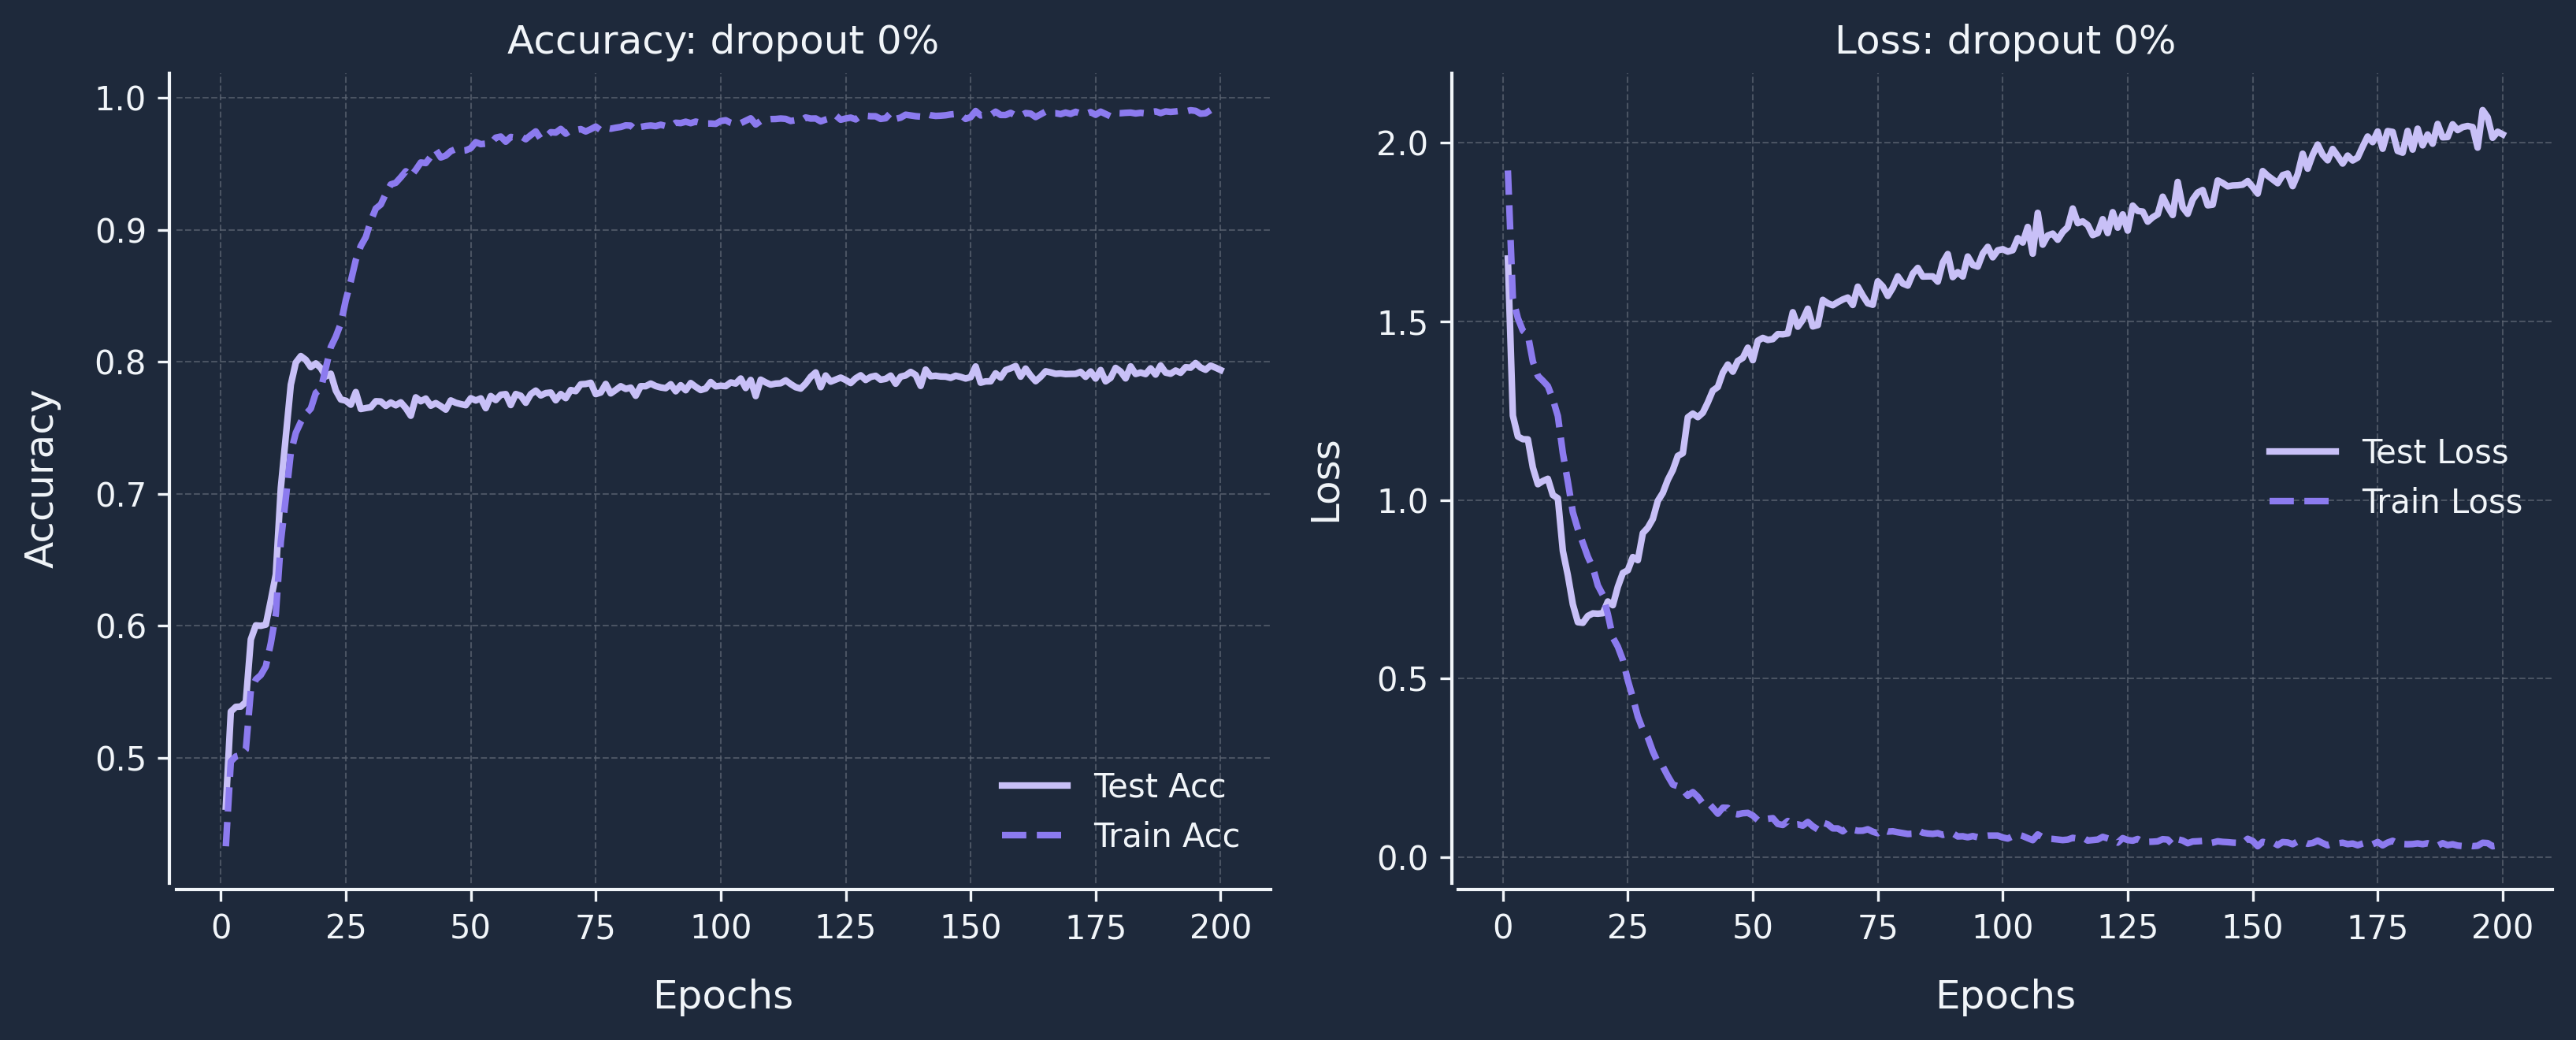

In [ ]:
train(run_name="dropout 0%", dropout_rate=0.0)

# 3) Dropout 5%

  🚀 Run: dropout 5%
Epoch      1 | Train loss 1.9230  acc 40.7% | Test loss 1.6848  acc 43.7%
Epoch      2 | Train loss 1.5746  acc 48.9% | Test loss 1.2160  acc 53.1%
Epoch      3 | Train loss 1.5129  acc 49.6% | Test loss 1.1616  acc 53.8%
Epoch      4 | Train loss 1.4823  acc 50.1% | Test loss 1.1741  acc 53.9%
Epoch      5 | Train loss 1.4671  acc 49.9% | Test loss 1.1449  acc 53.9%
Epoch      6 | Train loss 1.4639  acc 50.0% | Test loss 1.1539  acc 54.2%
Epoch      7 | Train loss 1.4536  acc 50.4% | Test loss 1.1245  acc 53.8%
Epoch      8 | Train loss 1.4423  acc 50.4% | Test loss 1.1488  acc 54.0%
Epoch      9 | Train loss 1.4291  acc 51.0% | Test loss 1.1482  acc 53.9%
Epoch     10 | Train loss 1.3649  acc 54.9% | Test loss 1.0641  acc 58.4%
Epoch     11 | Train loss 1.3242  acc 56.6% | Test loss 1.0453  acc 59.8%
Epoch     12 | Train loss 1.2852  acc 58.7% | Test loss 0.9961  acc 61.8%
Epoch     13 | Train loss 1.2094  acc 62.7% | Test loss 0.9007  acc 67.3%
Epoch     14 | Tra

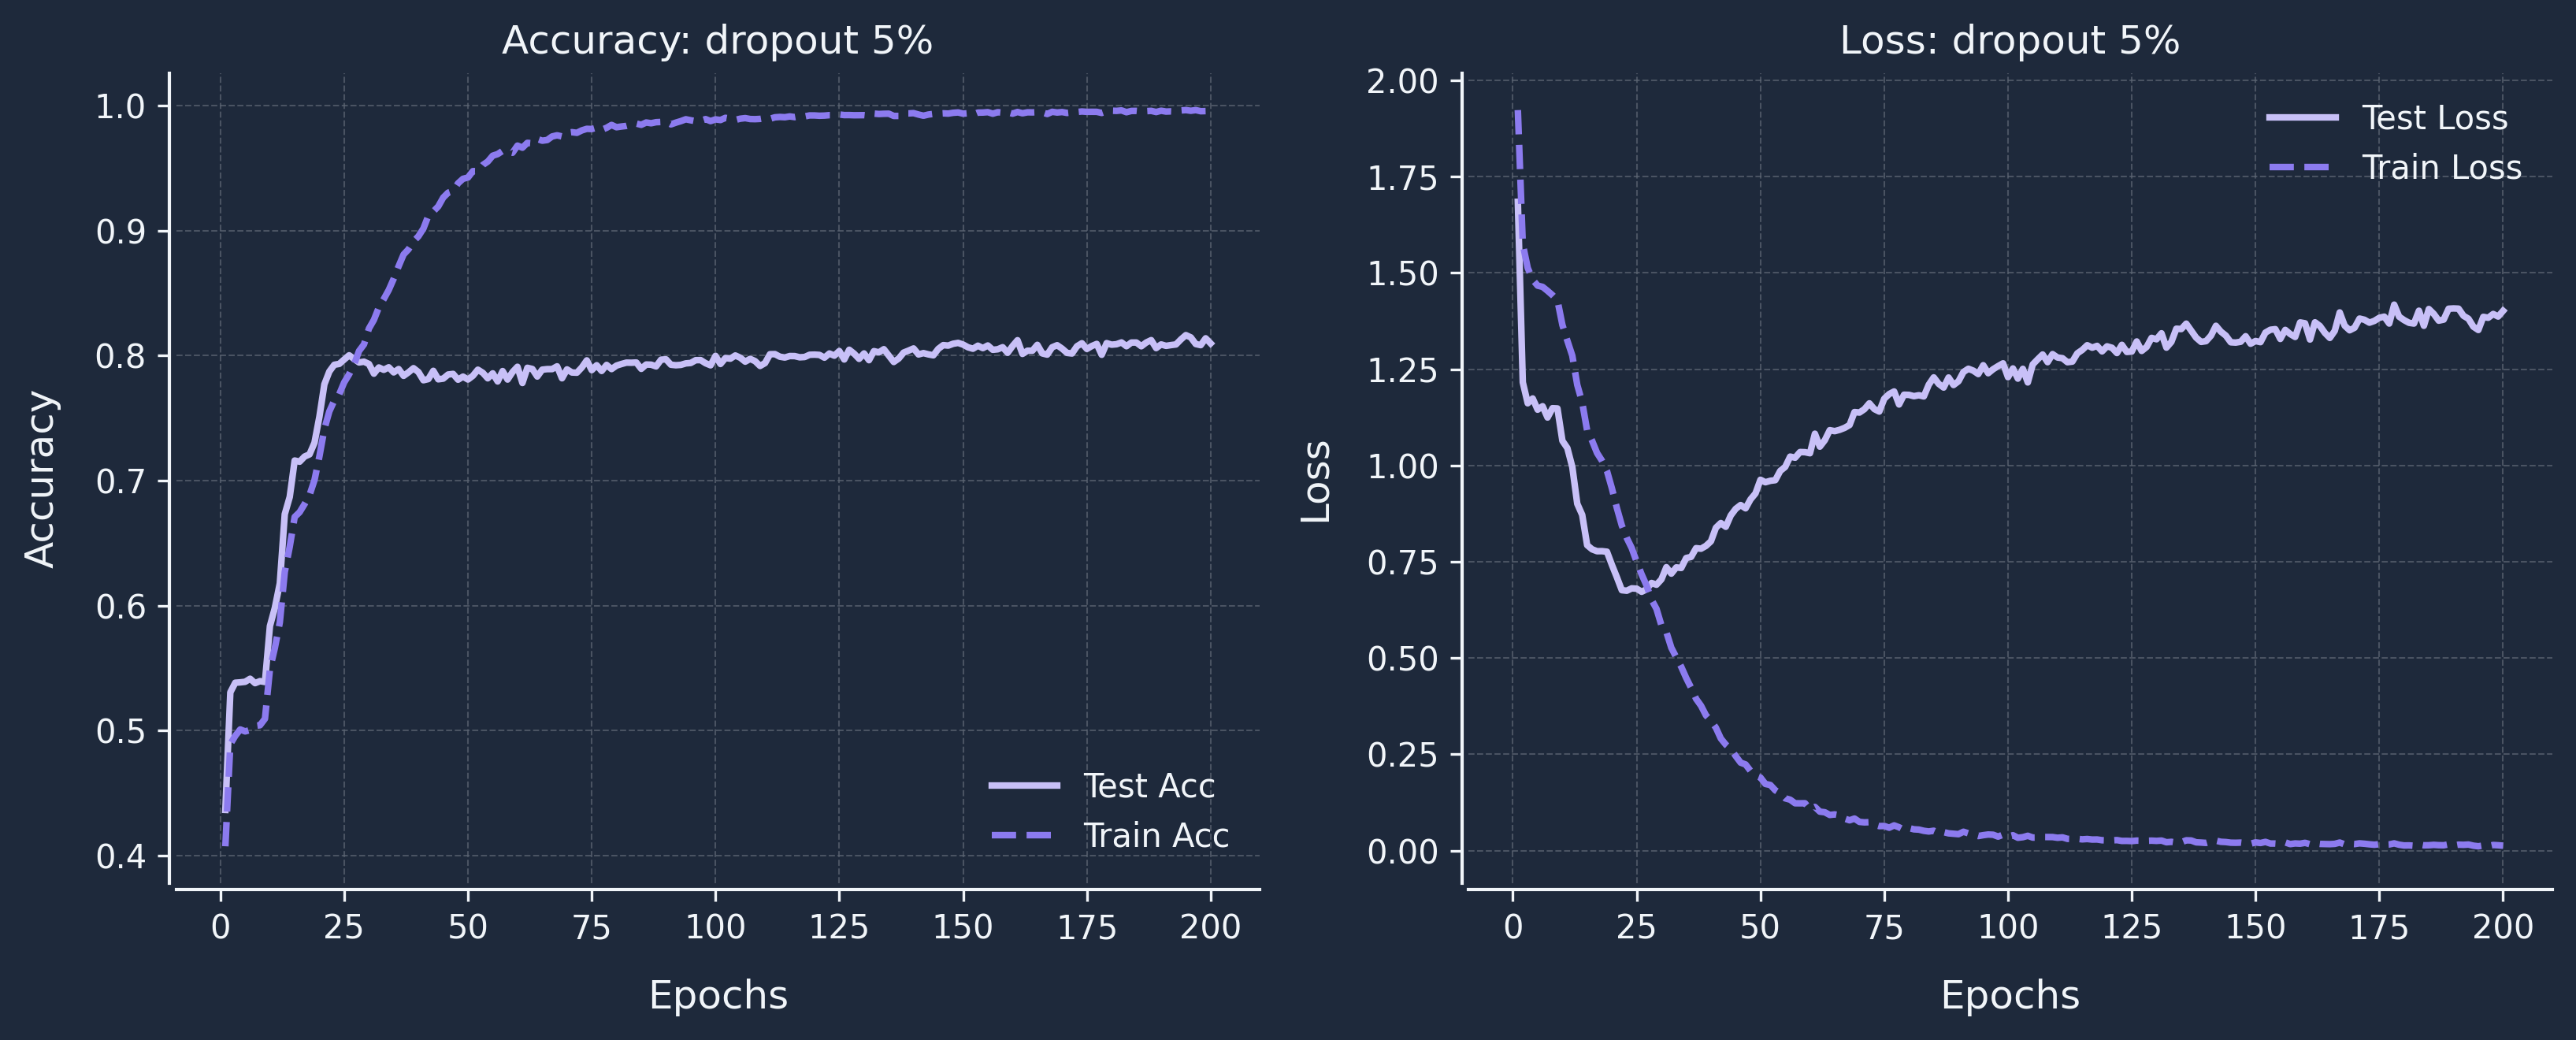

In [ ]:
train(run_name="dropout 5%", dropout_rate=0.05)

# 4) Dropout 10%

  🚀 Run: dropout 10%
Epoch      1 | Train loss 1.9938  acc 38.4% | Test loss 1.7537  acc 41.7%
Epoch      2 | Train loss 1.5852  acc 48.6% | Test loss 1.2250  acc 52.8%
Epoch      3 | Train loss 1.5147  acc 49.4% | Test loss 1.1619  acc 53.9%
Epoch      4 | Train loss 1.4816  acc 49.9% | Test loss 1.1565  acc 54.0%
Epoch      5 | Train loss 1.4699  acc 49.7% | Test loss 1.1433  acc 53.9%
Epoch      6 | Train loss 1.4648  acc 49.8% | Test loss 1.1319  acc 54.3%
Epoch      7 | Train loss 1.4575  acc 50.2% | Test loss 1.1128  acc 53.6%
Epoch      8 | Train loss 1.4542  acc 50.0% | Test loss 1.1439  acc 53.9%
Epoch      9 | Train loss 1.4396  acc 50.5% | Test loss 1.1361  acc 53.8%
Epoch     10 | Train loss 1.4279  acc 51.1% | Test loss 1.1238  acc 54.0%
Epoch     11 | Train loss 1.3531  acc 55.7% | Test loss 1.0540  acc 59.5%
Epoch     12 | Train loss 1.3256  acc 56.2% | Test loss 1.0081  acc 60.0%
Epoch     13 | Train loss 1.3168  acc 56.3% | Test loss 1.0085  acc 60.2%
Epoch     14 | Tr

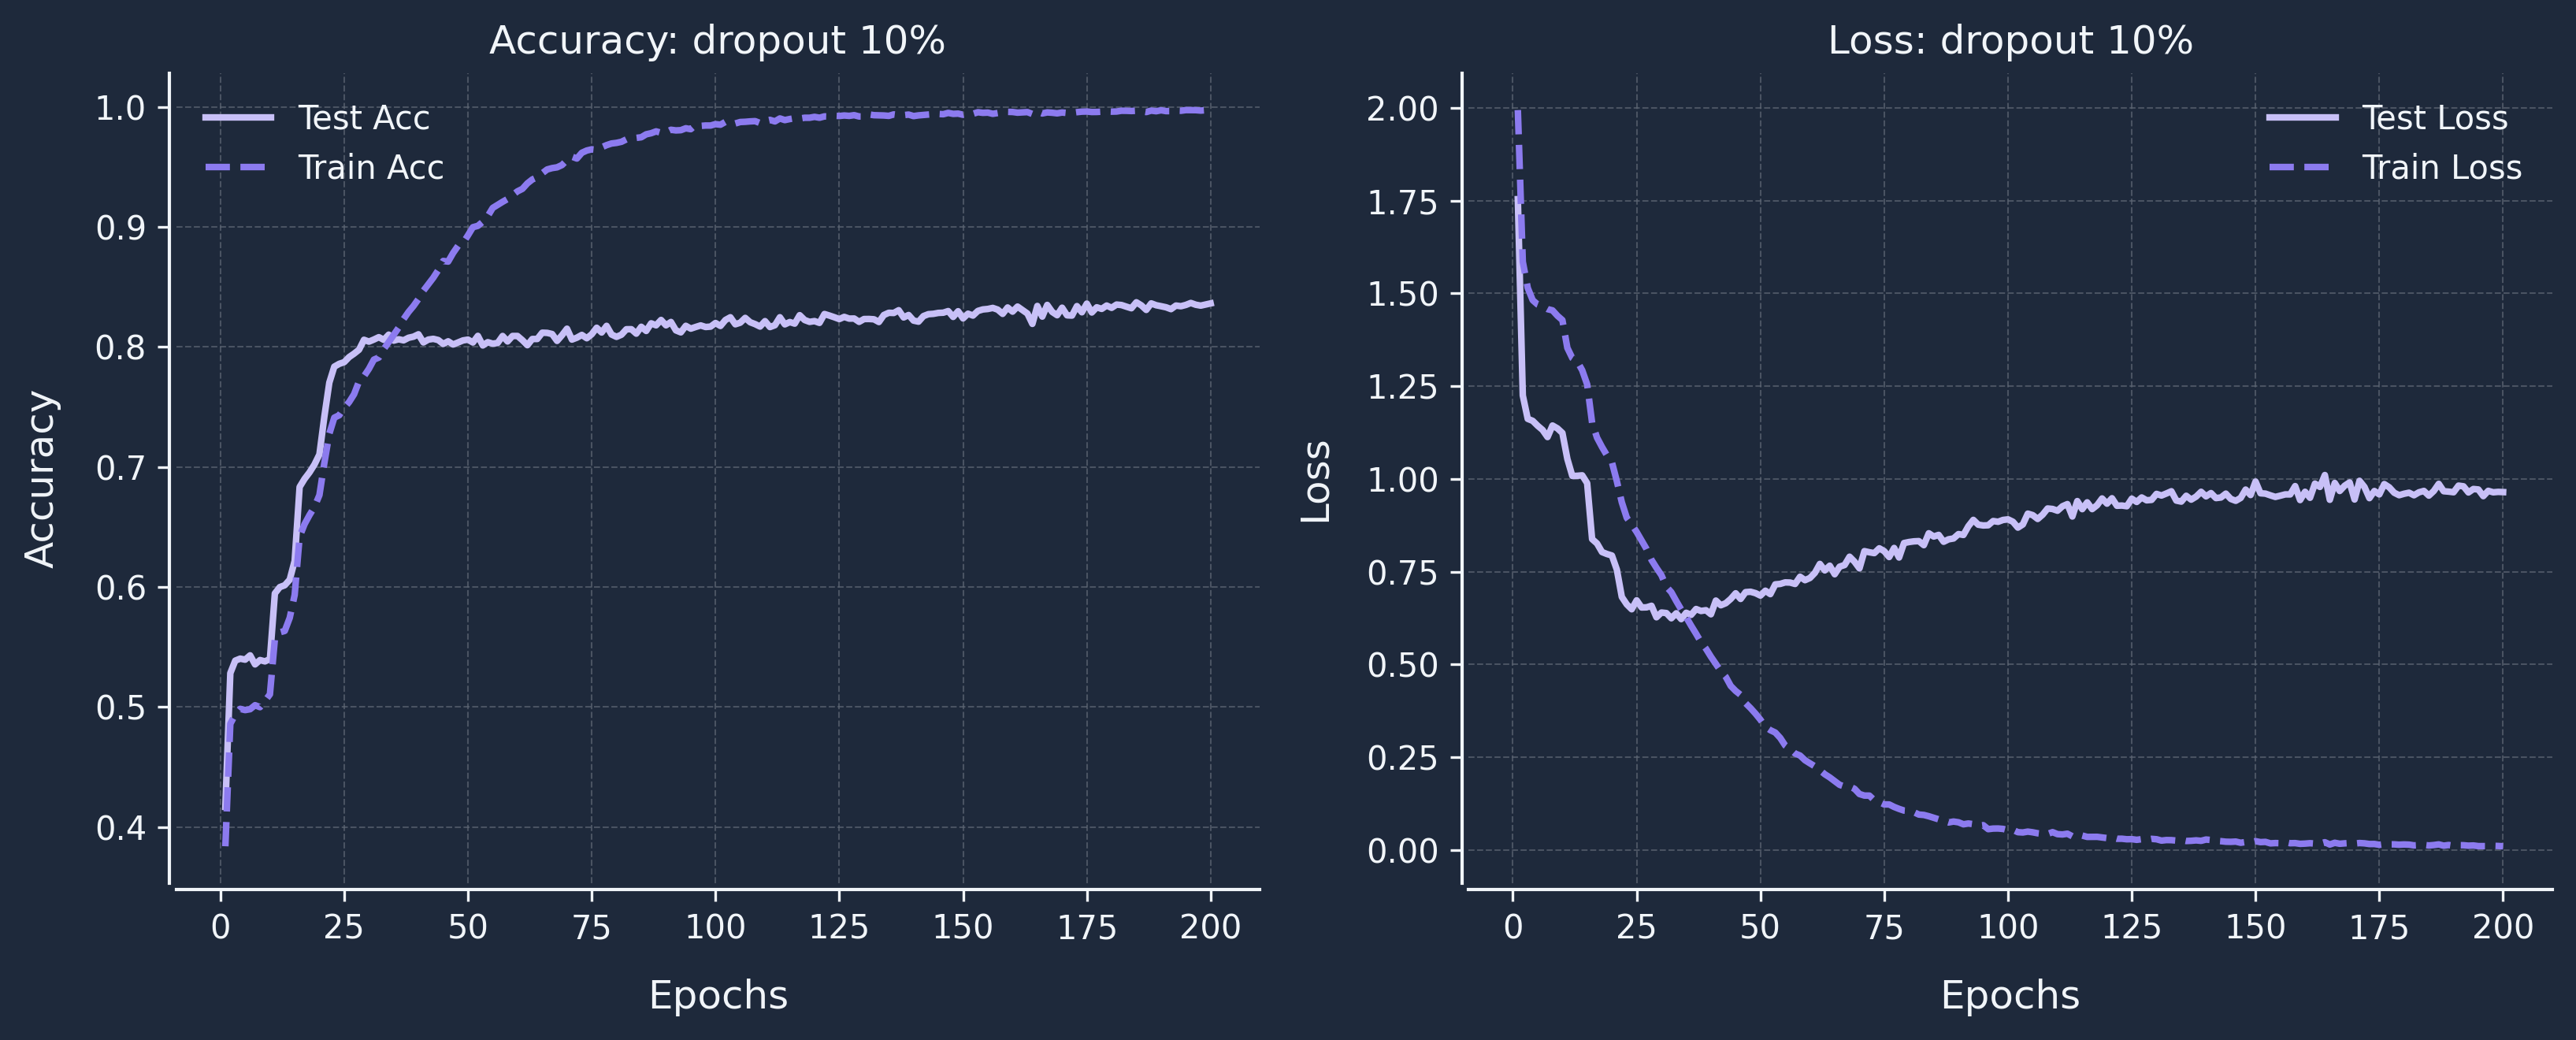

In [ ]:
train(run_name="dropout 10%", dropout_rate=0.1)

# 5) Dropout 20%

  🚀 Run: dropout 20%
Epoch      1 | Train loss 2.0872  acc 34.9% | Test loss 1.8637  acc 37.8%
Epoch      2 | Train loss 1.6282  acc 47.5% | Test loss 1.2722  acc 51.6%
Epoch      3 | Train loss 1.5258  acc 49.3% | Test loss 1.1402  acc 54.2%
Epoch      4 | Train loss 1.4825  acc 49.6% | Test loss 1.1449  acc 53.9%
Epoch      5 | Train loss 1.4774  acc 49.7% | Test loss 1.1423  acc 54.2%
Epoch      6 | Train loss 1.4657  acc 49.7% | Test loss 1.1330  acc 54.4%
Epoch      7 | Train loss 1.4589  acc 50.0% | Test loss 1.1028  acc 54.1%
Epoch      8 | Train loss 1.4620  acc 49.9% | Test loss 1.1382  acc 54.0%
Epoch      9 | Train loss 1.4491  acc 50.1% | Test loss 1.1195  acc 54.1%
Epoch     10 | Train loss 1.4428  acc 50.5% | Test loss 1.1145  acc 53.9%
Epoch     11 | Train loss 1.3816  acc 54.5% | Test loss 1.0663  acc 58.5%
Epoch     12 | Train loss 1.3455  acc 55.7% | Test loss 0.9962  acc 60.2%
Epoch     13 | Train loss 1.3449  acc 55.6% | Test loss 1.0083  acc 60.0%
Epoch     14 | Tr

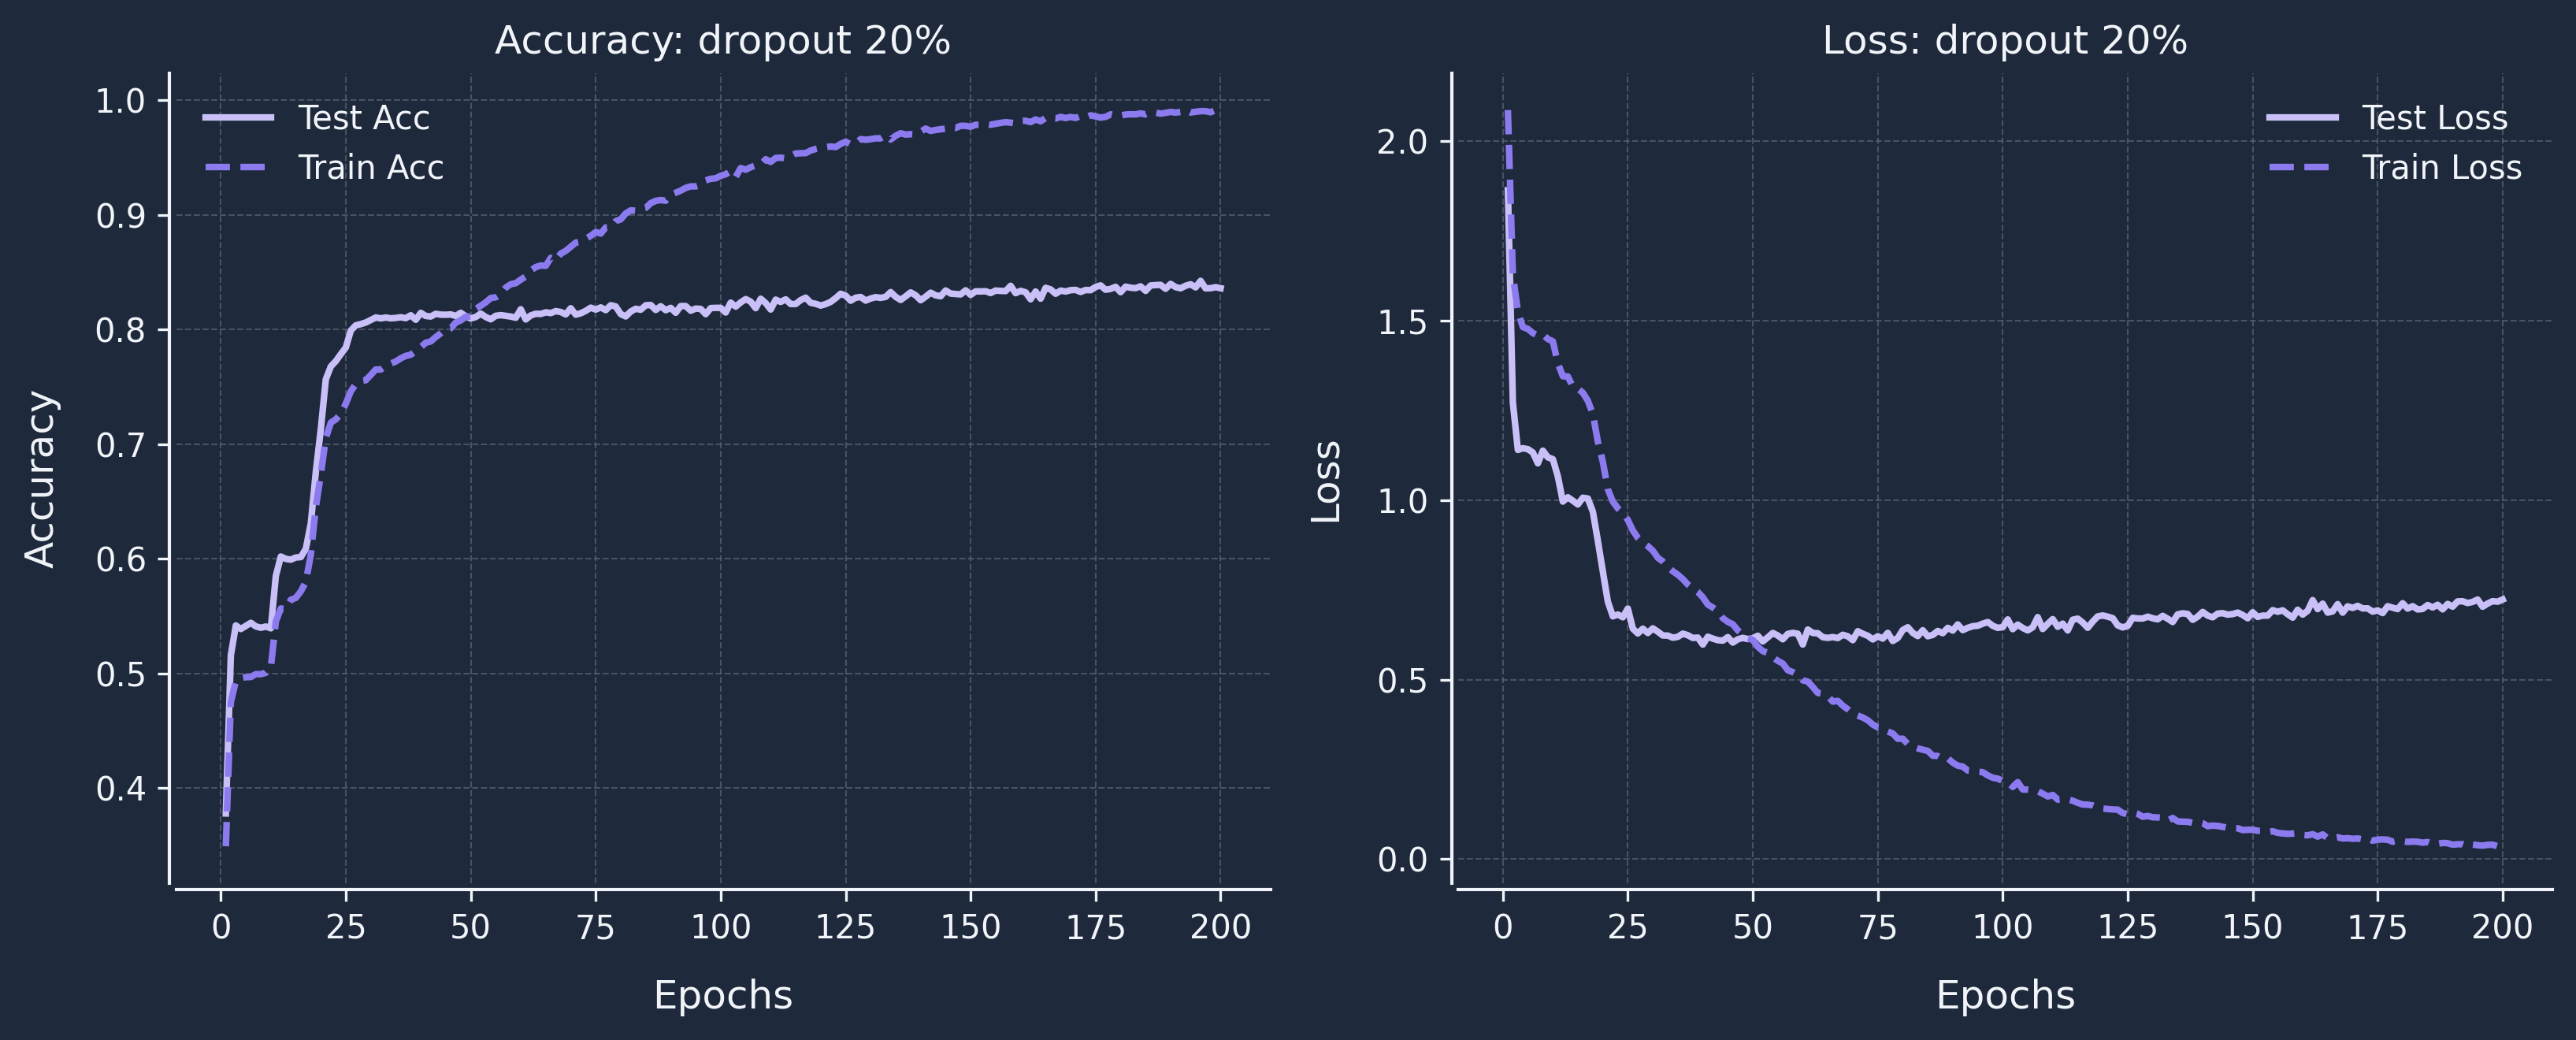

In [ ]:
train(run_name="dropout 20%", dropout_rate=0.2)

W0329 18:50:35.204000 1484 torch/_dynamo/convert_frame.py:1676] [1/8] torch._dynamo hit config.recompile_limit (8)
W0329 18:50:35.204000 1484 torch/_dynamo/convert_frame.py:1676] [1/8]    function: 'forward' (/tmp/ipykernel_1484/536879687.py:20)
W0329 18:50:35.204000 1484 torch/_dynamo/convert_frame.py:1676] [1/8]    last reason: 1/7: GLOBAL_STATE changed: grad_mode 
W0329 18:50:35.204000 1484 torch/_dynamo/convert_frame.py:1676] [1/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0329 18:50:35.204000 1484 torch/_dynamo/convert_frame.py:1676] [1/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/compile/programming_model.recompilation.html


  🚀 Run: dropout 25%
Epoch      1 | Train loss 2.1039  acc 34.1% | Test loss 1.8926  acc 36.8%
Epoch      2 | Train loss 1.6702  acc 46.6% | Test loss 1.3254  acc 50.4%
Epoch      3 | Train loss 1.5307  acc 49.0% | Test loss 1.1549  acc 53.7%
Epoch      4 | Train loss 1.4875  acc 49.7% | Test loss 1.1450  acc 54.2%
Epoch      5 | Train loss 1.4773  acc 49.8% | Test loss 1.1334  acc 53.9%
Epoch      6 | Train loss 1.4718  acc 49.8% | Test loss 1.1339  acc 54.3%
Epoch      7 | Train loss 1.4686  acc 49.9% | Test loss 1.0988  acc 54.1%
Epoch      8 | Train loss 1.4721  acc 49.7% | Test loss 1.1454  acc 54.3%
Epoch      9 | Train loss 1.4530  acc 49.9% | Test loss 1.1233  acc 53.9%
Epoch     10 | Train loss 1.4460  acc 50.1% | Test loss 1.1122  acc 54.1%
Epoch     11 | Train loss 1.4519  acc 50.3% | Test loss 1.1526  acc 54.0%
Epoch     12 | Train loss 1.4414  acc 50.3% | Test loss 1.1180  acc 53.9%
Epoch     13 | Train loss 1.4303  acc 50.6% | Test loss 1.1087  acc 54.3%
Epoch     14 | Tr

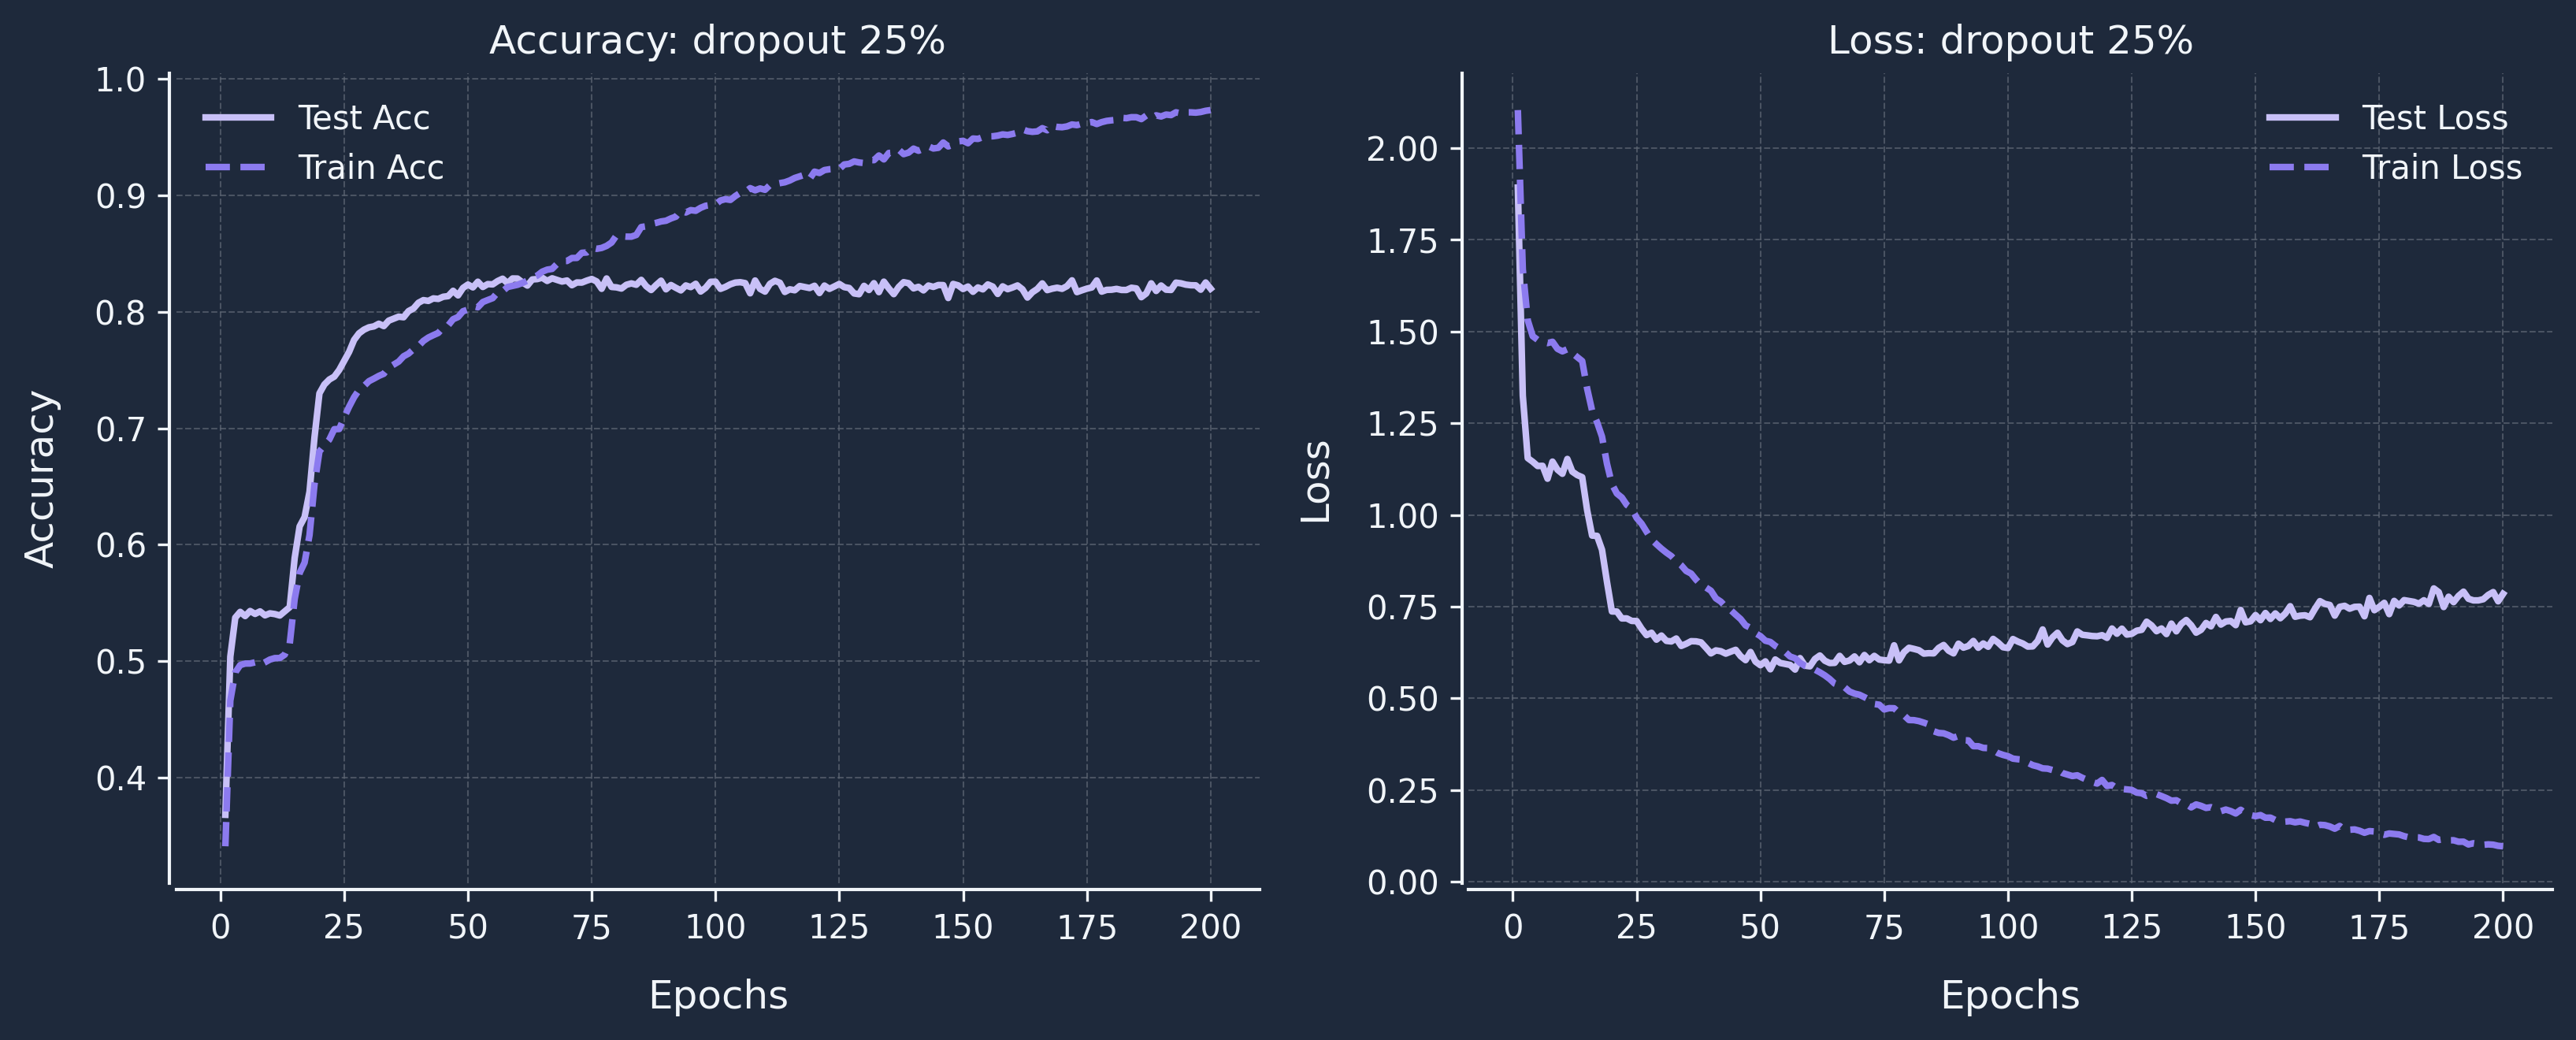

In [ ]:
train(run_name="dropout 25%", dropout_rate=0.25)

# 6) Dropout 30%

  🚀 Run: dropout 30%
Epoch      1 | Train loss 2.1335  acc 32.9% | Test loss 1.9197  acc 35.4%
Epoch      2 | Train loss 1.7311  acc 44.8% | Test loss 1.3943  acc 48.7%
Epoch      3 | Train loss 1.5471  acc 48.6% | Test loss 1.1809  acc 53.0%
Epoch      4 | Train loss 1.4947  acc 49.5% | Test loss 1.1427  acc 53.9%
Epoch      5 | Train loss 1.4845  acc 49.7% | Test loss 1.1267  acc 54.0%
Epoch      6 | Train loss 1.4724  acc 49.7% | Test loss 1.1226  acc 54.4%
Epoch      7 | Train loss 1.4682  acc 49.9% | Test loss 1.1035  acc 54.0%
Epoch      8 | Train loss 1.4731  acc 49.8% | Test loss 1.1245  acc 54.2%
Epoch      9 | Train loss 1.4566  acc 49.9% | Test loss 1.1249  acc 54.1%
Epoch     10 | Train loss 1.4540  acc 50.0% | Test loss 1.1008  acc 54.1%
Epoch     11 | Train loss 1.4617  acc 50.1% | Test loss 1.1440  acc 53.7%
Epoch     12 | Train loss 1.4465  acc 50.2% | Test loss 1.1180  acc 53.9%
Epoch     13 | Train loss 1.4461  acc 50.0% | Test loss 1.1138  acc 54.1%
Epoch     14 | Tr

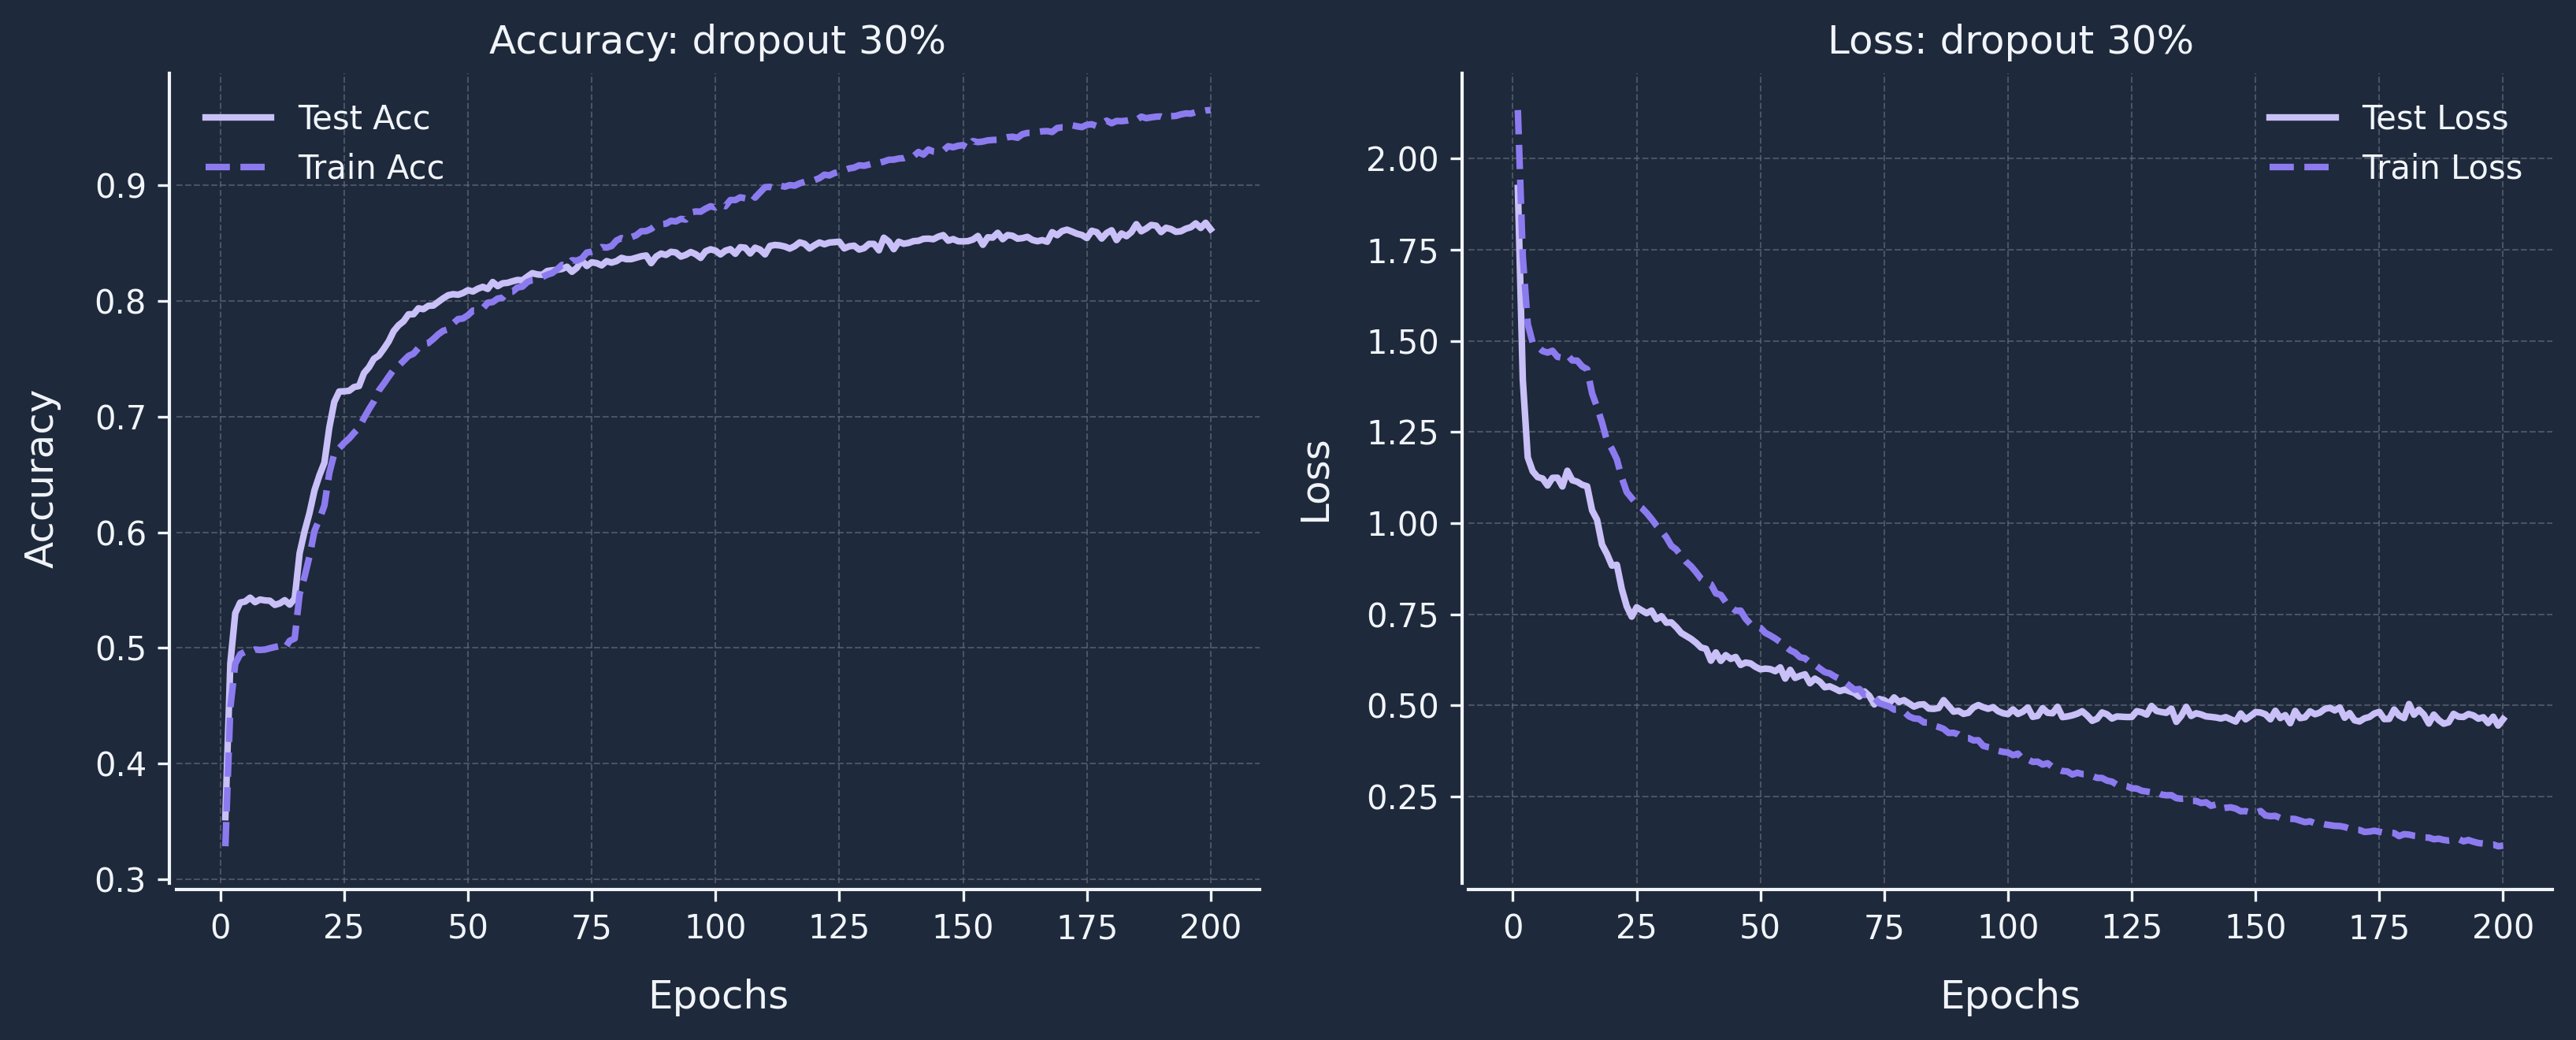

In [ ]:
train(run_name="dropout 30%", dropout_rate=0.3)

# 7) Dropout 40%

  🚀 Run: dropout 40%
Epoch      1 | Train loss 2.1698  acc 31.7% | Test loss 1.9704  acc 34.2%
Epoch      2 | Train loss 1.8880  acc 40.6% | Test loss 1.6173  acc 44.1%
Epoch      3 | Train loss 1.5898  acc 48.1% | Test loss 1.2357  acc 52.7%
Epoch      4 | Train loss 1.5128  acc 49.5% | Test loss 1.1599  acc 54.2%
Epoch      5 | Train loss 1.4888  acc 49.7% | Test loss 1.1194  acc 54.4%
Epoch      6 | Train loss 1.4808  acc 49.7% | Test loss 1.1279  acc 54.2%
Epoch      7 | Train loss 1.4866  acc 49.8% | Test loss 1.0967  acc 54.2%
Epoch      8 | Train loss 1.4757  acc 49.8% | Test loss 1.1220  acc 54.3%
Epoch      9 | Train loss 1.4652  acc 49.7% | Test loss 1.1085  acc 54.3%
Epoch     10 | Train loss 1.4590  acc 49.8% | Test loss 1.1032  acc 54.1%
Epoch     11 | Train loss 1.4675  acc 50.0% | Test loss 1.1358  acc 54.0%
Epoch     12 | Train loss 1.4558  acc 49.9% | Test loss 1.1085  acc 54.3%
Epoch     13 | Train loss 1.4554  acc 50.0% | Test loss 1.0908  acc 54.6%
Epoch     14 | Tr

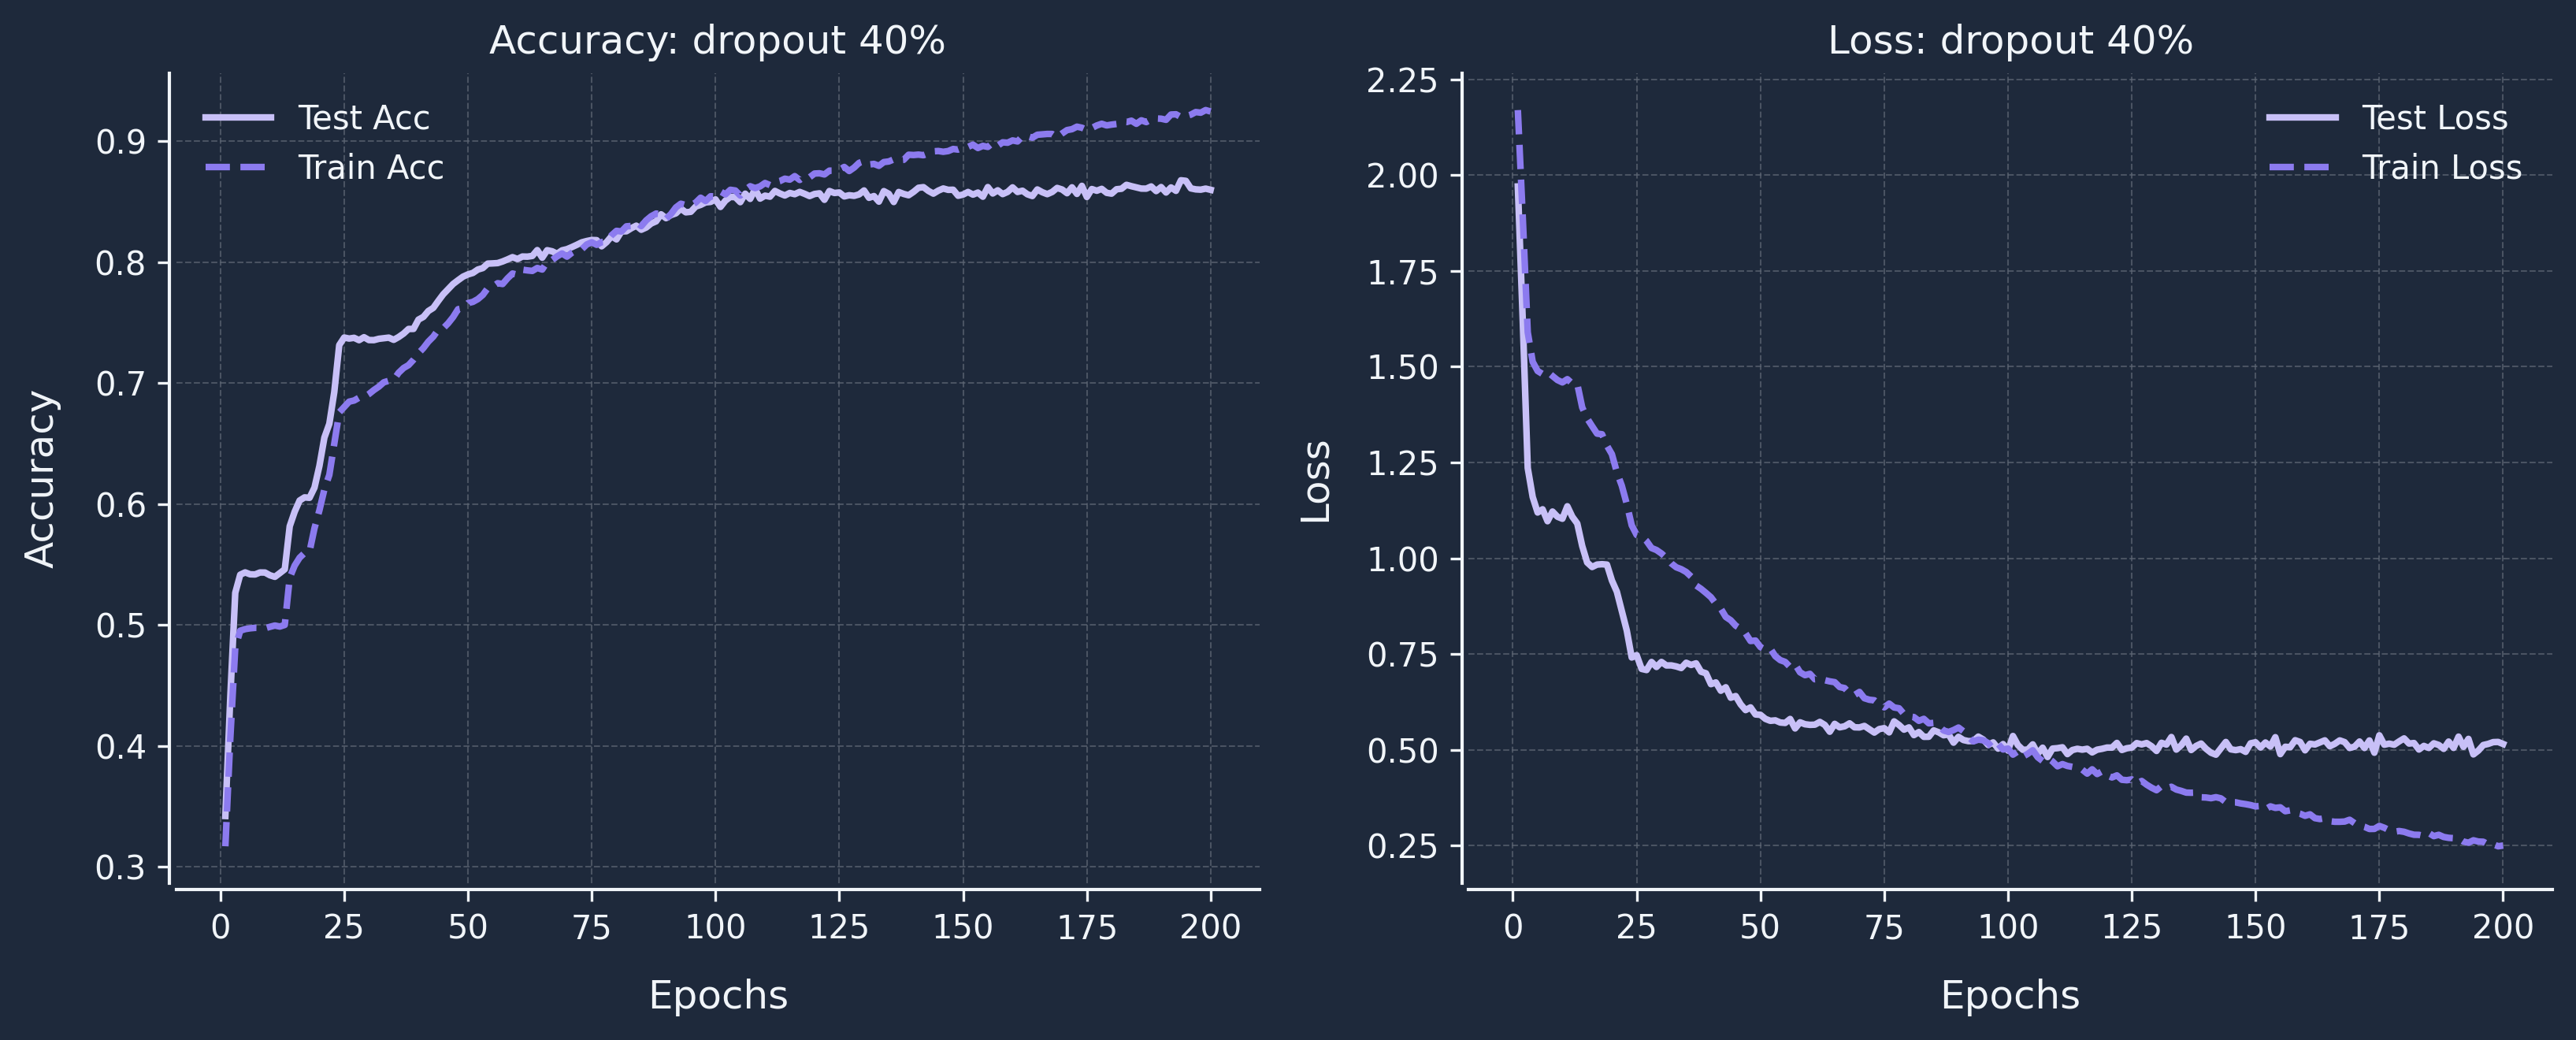

In [ ]:
train(run_name="dropout 40%", dropout_rate=0.4)

# 8) Dropout 50%

  🚀 Run: dropout 50%
Epoch      1 | Train loss 2.2356  acc 30.9% | Test loss 2.0523  acc 33.5%
Epoch      2 | Train loss 2.0527  acc 34.8% | Test loss 1.8302  acc 38.0%
Epoch      3 | Train loss 1.7109  acc 45.5% | Test loss 1.3877  acc 49.6%
Epoch      4 | Train loss 1.5471  acc 49.1% | Test loss 1.2110  acc 53.6%
Epoch      5 | Train loss 1.5029  acc 49.6% | Test loss 1.1465  acc 53.9%
Epoch      6 | Train loss 1.5039  acc 49.8% | Test loss 1.1574  acc 54.1%
Epoch      7 | Train loss 1.4866  acc 49.6% | Test loss 1.1222  acc 54.3%
Epoch      8 | Train loss 1.4894  acc 49.7% | Test loss 1.1385  acc 54.3%
Epoch      9 | Train loss 1.4779  acc 49.7% | Test loss 1.1324  acc 54.1%
Epoch     10 | Train loss 1.4705  acc 49.9% | Test loss 1.1218  acc 54.3%
Epoch     11 | Train loss 1.4770  acc 50.0% | Test loss 1.1386  acc 54.1%
Epoch     12 | Train loss 1.4685  acc 50.0% | Test loss 1.1097  acc 54.2%
Epoch     13 | Train loss 1.4586  acc 50.1% | Test loss 1.0914  acc 54.3%
Epoch     14 | Tr

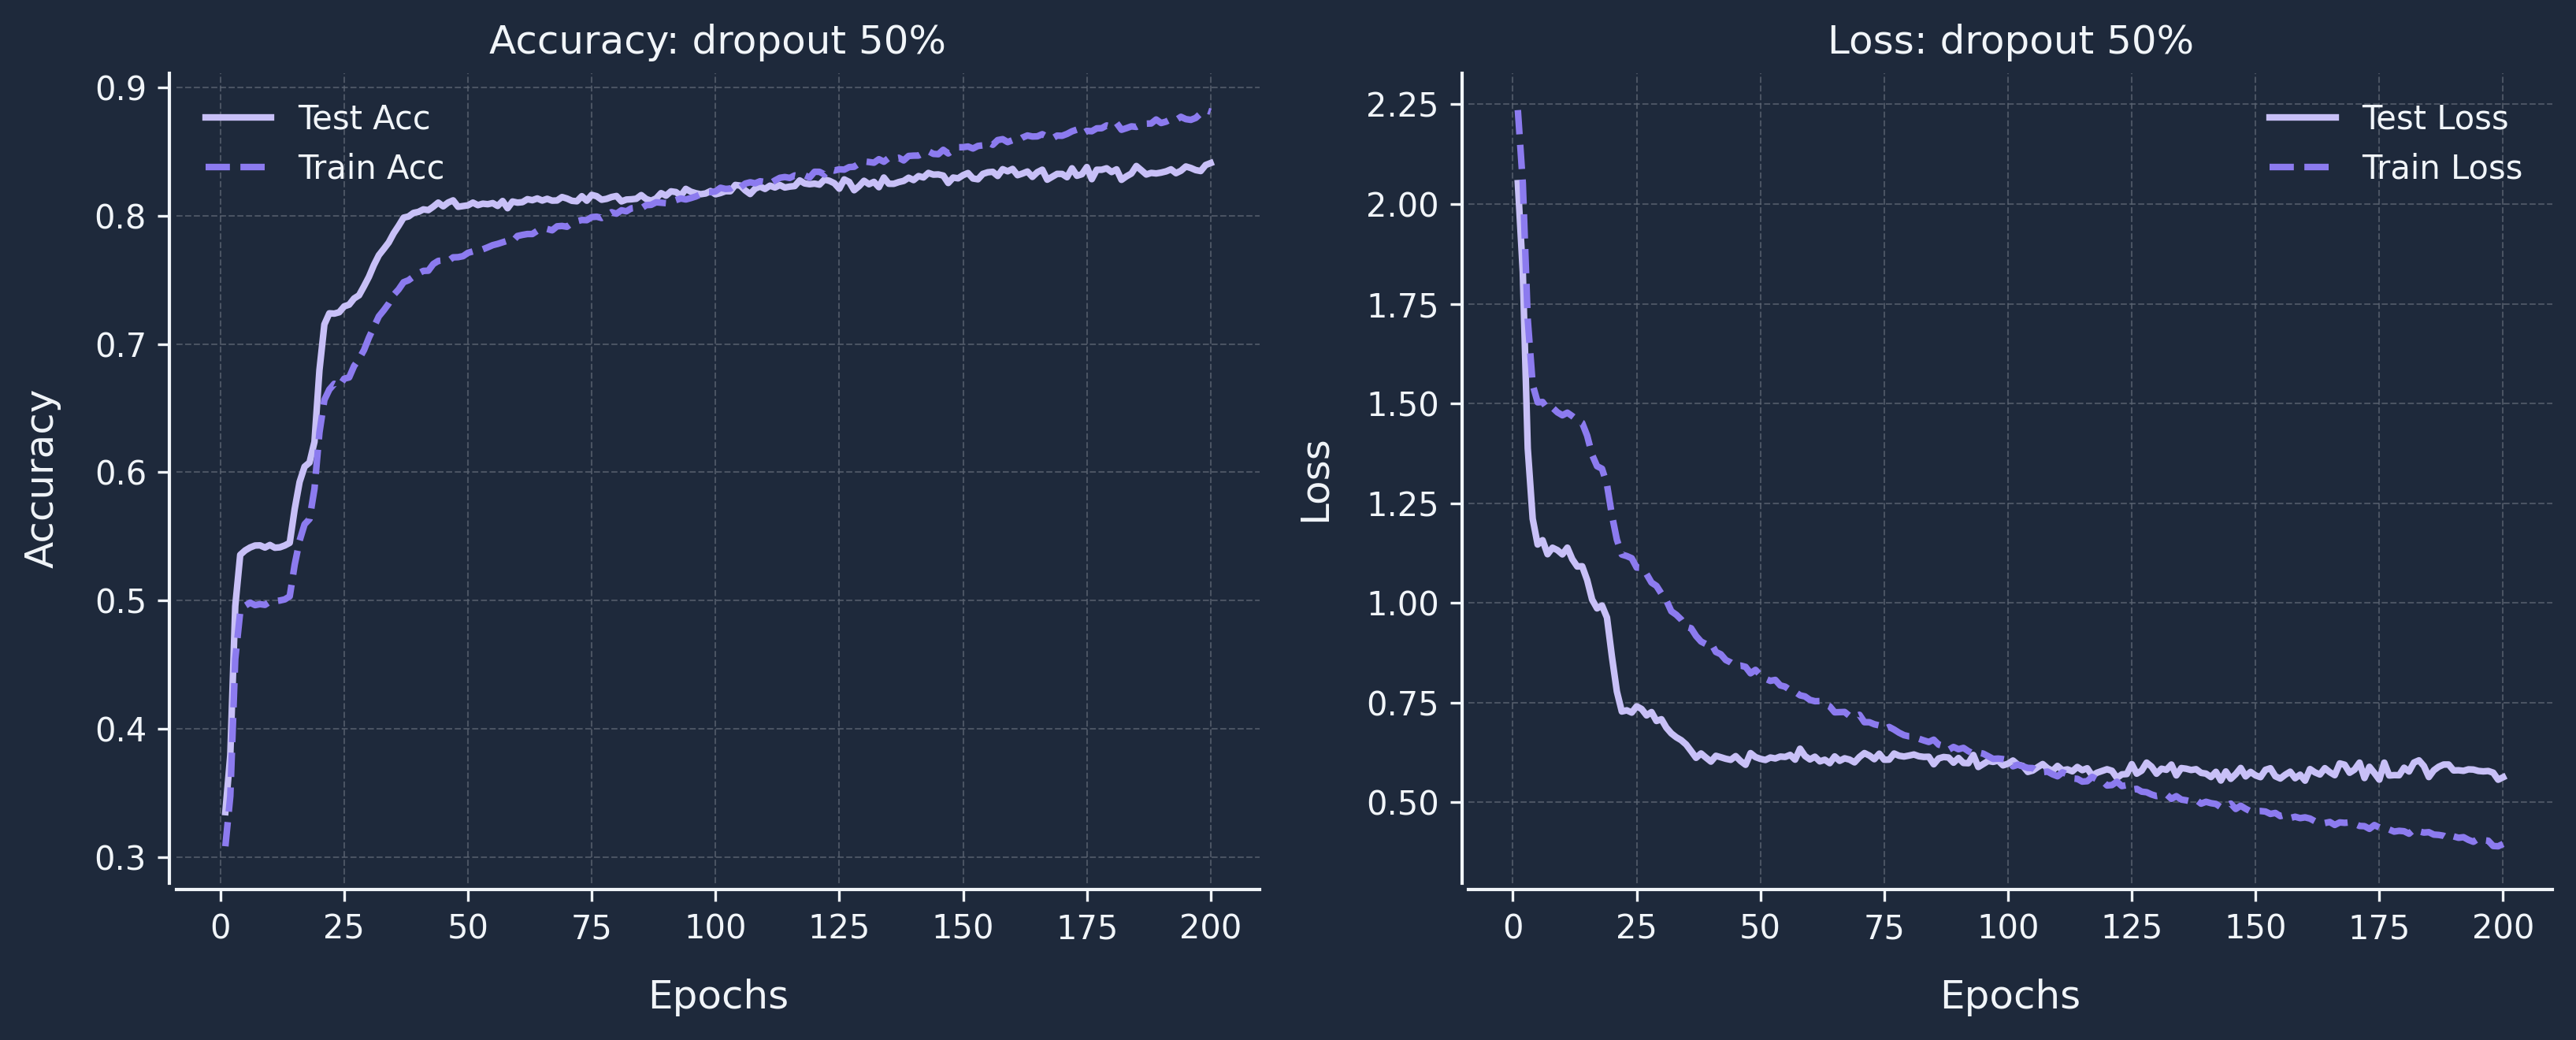

In [ ]:
train(run_name="dropout 50%", dropout_rate=0.5)

# 9) Dropout 10% + Weight Decay 1e-3

  🚀 Run: dropout 10% + wd 1e-3
Epoch      1 | Train loss 2.0125  acc 38.3% | Test loss 1.7752  acc 41.2%
Epoch      2 | Train loss 1.5819  acc 48.5% | Test loss 1.2130  acc 52.8%
Epoch      3 | Train loss 1.5050  acc 49.7% | Test loss 1.1475  acc 54.2%
Epoch      4 | Train loss 1.4842  acc 49.9% | Test loss 1.1607  acc 53.9%
Epoch      5 | Train loss 1.4704  acc 49.8% | Test loss 1.1353  acc 54.1%
Epoch      6 | Train loss 1.4654  acc 50.0% | Test loss 1.1439  acc 54.1%
Epoch      7 | Train loss 1.4566  acc 50.3% | Test loss 1.1163  acc 53.7%
Epoch      8 | Train loss 1.4528  acc 50.0% | Test loss 1.1498  acc 54.1%
Epoch      9 | Train loss 1.4327  acc 50.7% | Test loss 1.1332  acc 54.1%
Epoch     10 | Train loss 1.3787  acc 54.2% | Test loss 1.0702  acc 57.8%
Epoch     11 | Train loss 1.3507  acc 55.7% | Test loss 1.0537  acc 59.1%
Epoch     12 | Train loss 1.3246  acc 56.3% | Test loss 1.0098  acc 59.8%
Epoch     13 | Train loss 1.3221  acc 56.1% | Test loss 1.0151  acc 59.9%
Epoch  

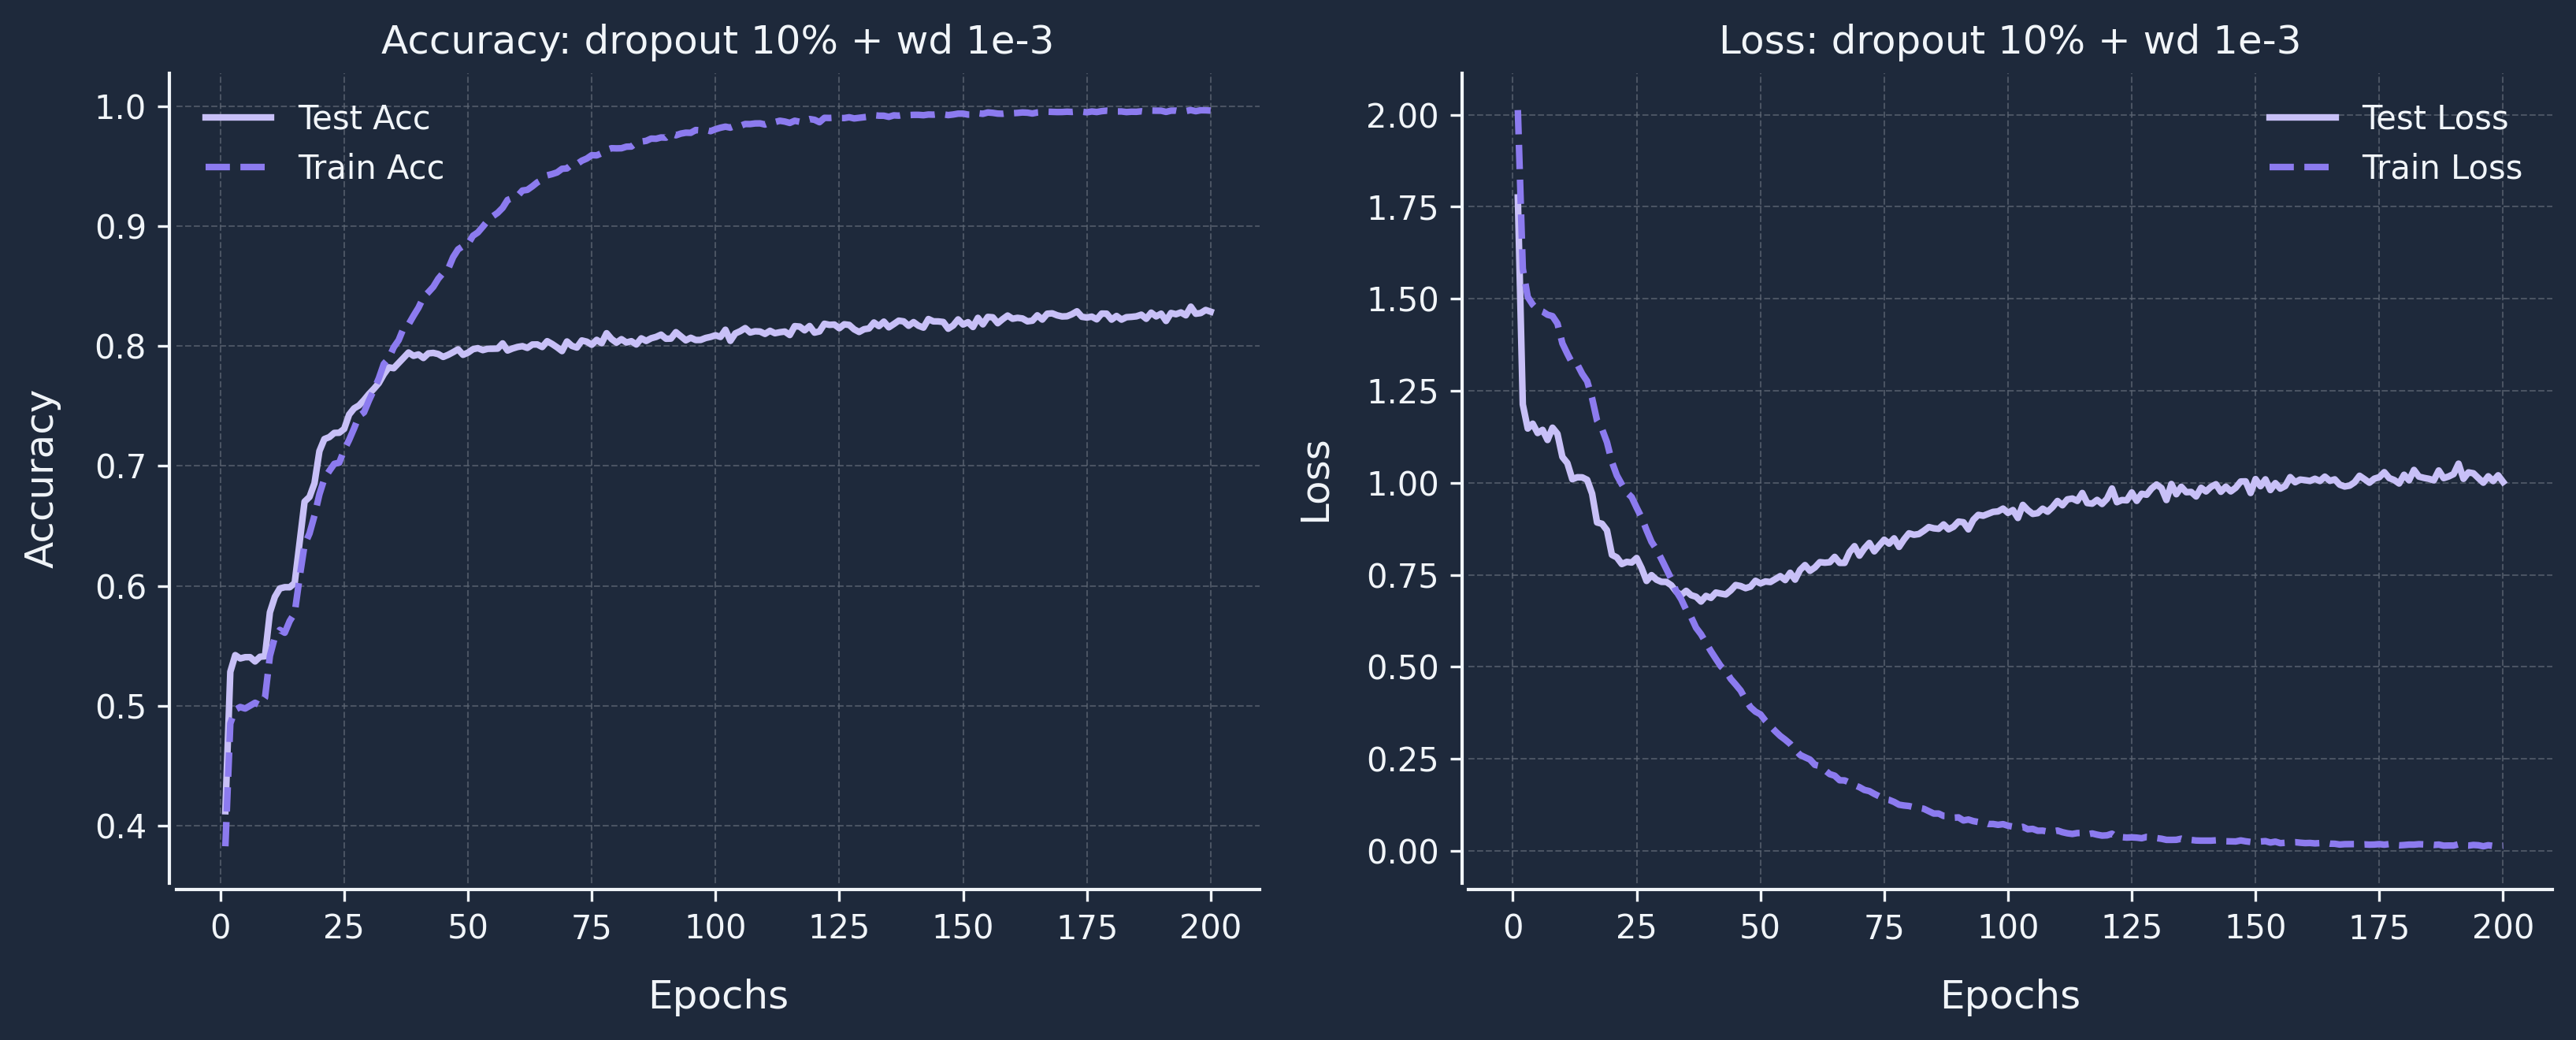

In [ ]:
train(run_name="dropout 10% + wd 1e-3", dropout_rate=0.1, weight_decay=0.001)

# 10) Loss + Accuracy across runs

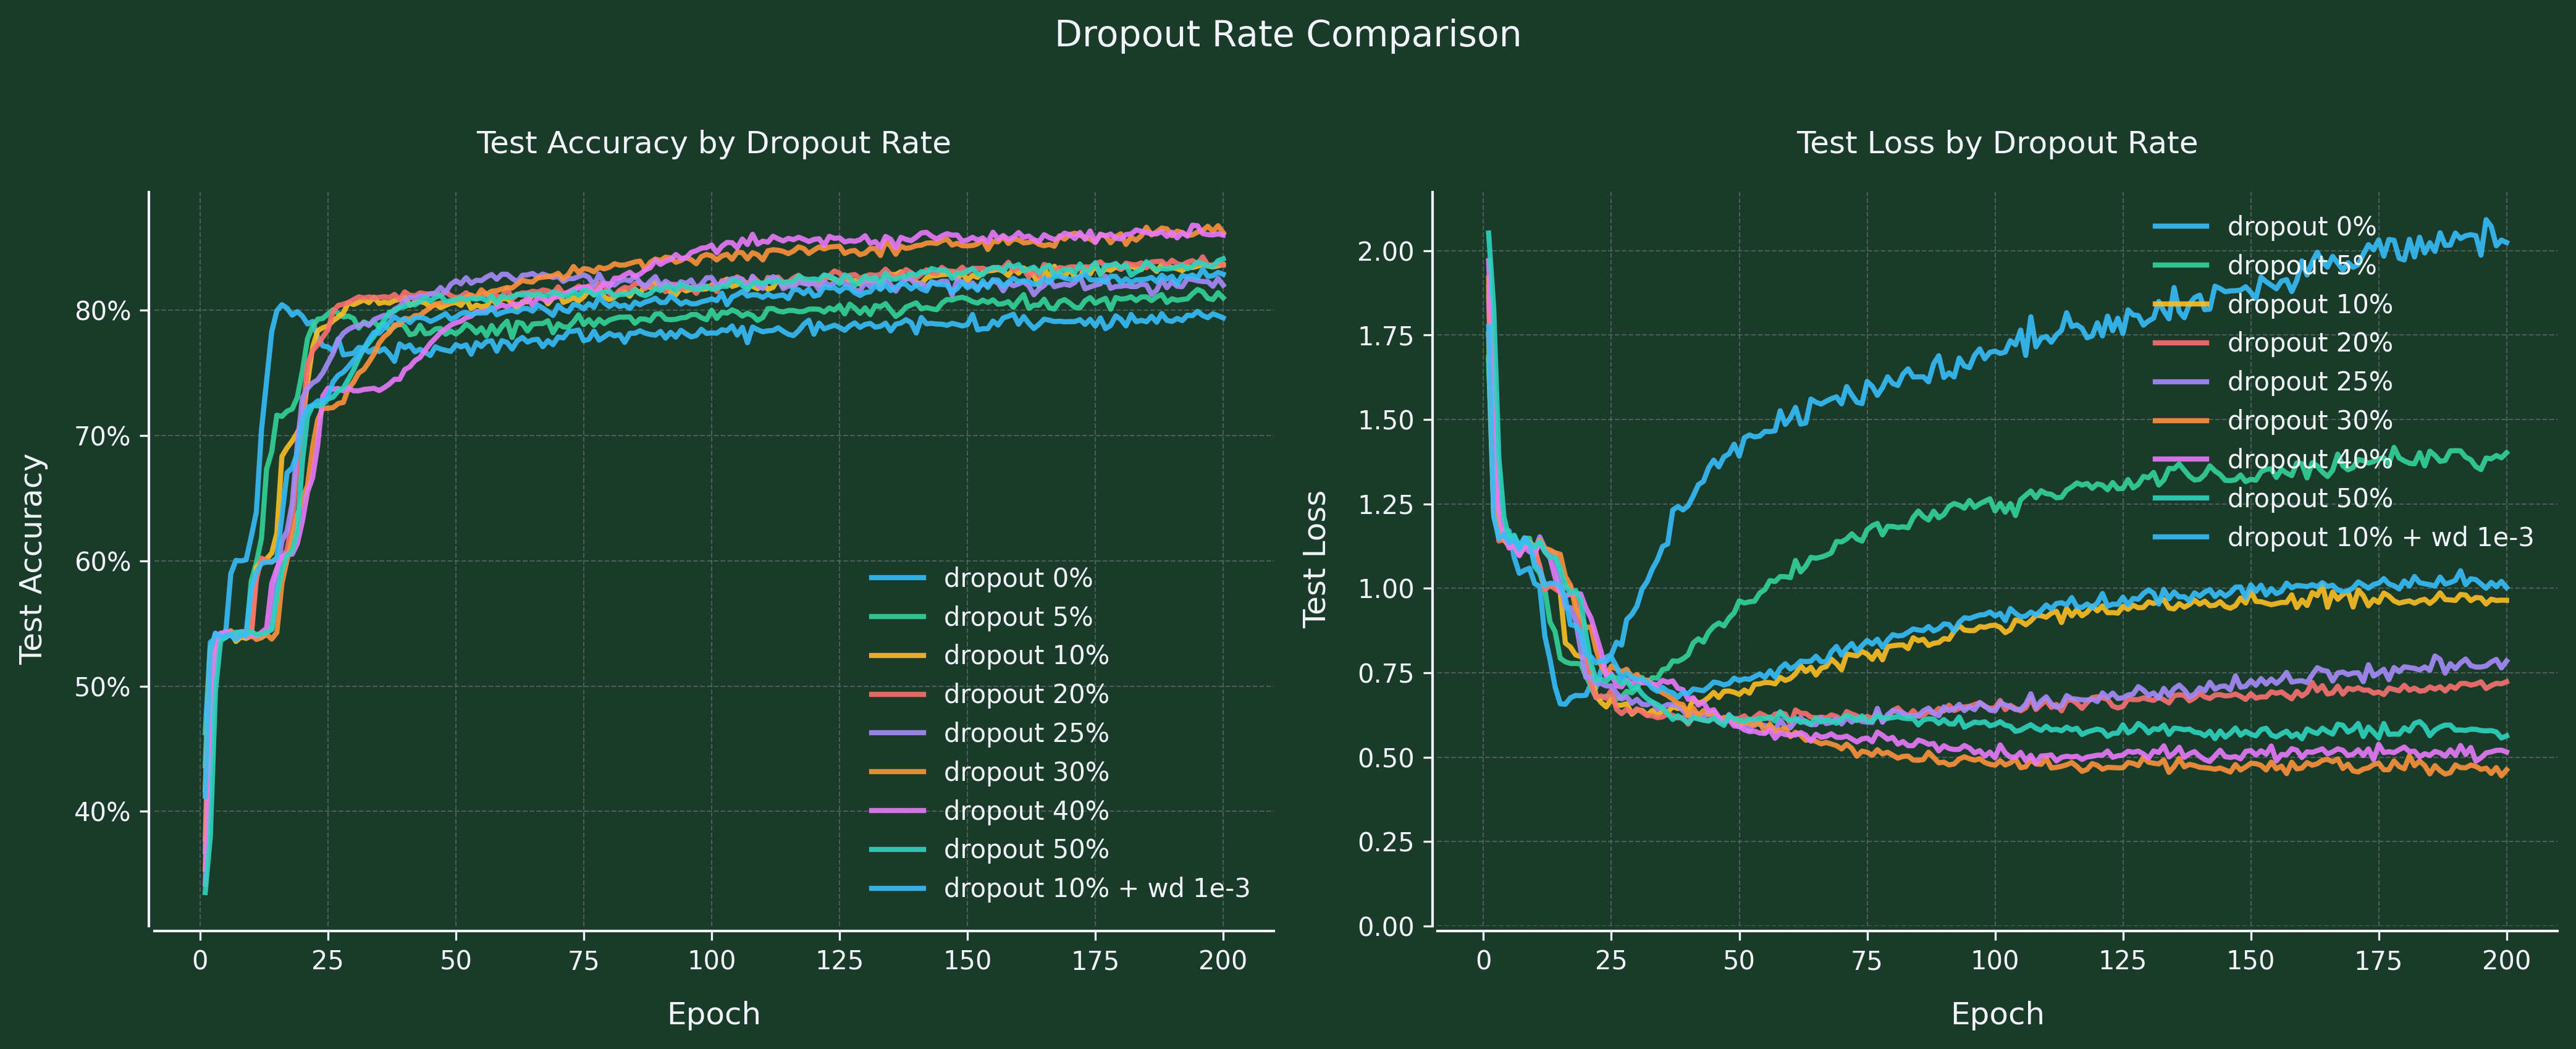


Run                            Converged Epoch      Final Test Acc 
-----------------------------------------------------------------
dropout 0%                     Did not converge     79.4%
dropout 5%                     Did not converge     81.0%
dropout 10%                    Did not converge     83.6%
dropout 20%                    Did not converge     83.6%
dropout 25%                    Did not converge     82.0%
dropout 30%                    Did not converge     86.2%
dropout 40%                    Did not converge     86.0%
dropout 50%                    Did not converge     84.1%
dropout 10% + wd 1e-3          Did not converge     82.9%


In [ ]:
#@title Visualize
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import logging
import matplotlib.ticker as ticker

# Suppress missing font warnings
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Prefer the deployment font when available, otherwise fall back to common sans-serif fonts
font_candidates = ['Inter', 'DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['font.family'] = font_candidates
font_path = 'fonts/Inter-Regular.ttf'
try:
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
except Exception:
    pass

# Set styling for all text and lines
plt.rcParams['text.color'] = '#F1F5F9'
plt.rcParams['axes.labelcolor'] = '#F1F5F9'
plt.rcParams['xtick.color'] = '#F1F5F9'
plt.rcParams['ytick.color'] = '#F1F5F9'
plt.rcParams['axes.edgecolor'] = '#F1F5F9'

# Grid styling
plt.rcParams['grid.color'] = '#5B7268'
plt.rcParams['grid.alpha'] = 0.7

def _coplot_luminance_from_rgba(rgba):
    r, g, b = mcolors.to_rgb(rgba)
    def _linear(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    return 0.2126 * _linear(r) + 0.7152 * _linear(g) + 0.0722 * _linear(b)

def _coplot_text_color_for_rgba(rgba, preferred='#F1F5F9'):
    try:
        preferred_l = _coplot_luminance_from_rgba(mcolors.to_rgba(preferred))
        bg_l = _coplot_luminance_from_rgba(rgba)
        lighter = max(preferred_l, bg_l)
        darker = min(preferred_l, bg_l)
        ratio = (lighter + 0.05) / (darker + 0.05)
        if ratio >= 4.5:
            return preferred
    except Exception:
        pass
    bg_l = _coplot_luminance_from_rgba(rgba)
    return '#111111' if bg_l > 0.5 else '#FFFFFF'

# Create figure and axis with publication-quality settings
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300)
fig.patch.set_facecolor('#1A3A2A')

# Distinct bright colors for dark background
colors = ["#38BDF8", "#34D399", "#FBBF24", "#F87171", "#A78BFA", "#FB923C", "#E879F9", "#2DD4BF"]
line_styles = ["-","--",":","-."]*2
marker_styles = ["o","s","^","D"]*2

for idx, run in enumerate(all_runs):
    h = run["history"]

    # Plot accuracy
    axes[0].plot(h["epoch"], h["test_acc"], label=run["name"],
                 color=colors[idx % len(colors)], linewidth=2, alpha=0.9)

    # Plot loss
    axes[1].plot(h["epoch"], h["test_loss"], label=run["name"],
                 color=colors[idx % len(colors)], linewidth=2, alpha=0.9)

# Apply custom styling to both axes
for ax in axes:
    ax.set_facecolor('#1A3A2A')
    ax.set_xlabel('Epoch', fontsize=12, labelpad=10, color='#F1F5F9')

    # Force integer epochs
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # Add grid
    ax.grid(axis='both', alpha=0.7, color='#5B7268', linestyle='--', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_color('#F1F5F9')
    ax.spines['left'].set_color('#F1F5F9')

    # Adjust spine positions
    ax.spines['left'].set_position(('outward', 2))
    ax.spines['bottom'].set_position(('outward', 2))

    # Add legend
    ax.legend(frameon=False, fontsize=10)

# Specific titles and labels
axes[0].set_ylabel('Test Accuracy', fontsize=12, color='#F1F5F9', labelpad=10)
axes[0].set_title('Test Accuracy by Dropout Rate', color='#F1F5F9', pad=15)
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

axes[1].set_ylabel('Test Loss', fontsize=12, color='#F1F5F9', labelpad=10)
axes[1].set_title('Test Loss by Dropout Rate', color='#F1F5F9', pad=15)
axes[1].set_yscale('linear')
axes[1].set_ylim(bottom=0.0)
axes[1].yaxis.set_major_formatter(ticker.ScalarFormatter())

# Global title
plt.suptitle("Dropout Rate Comparison", fontsize=14, y=1.02, color='#F1F5F9')

# Tight layout
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Run':<30s} {'Converged Epoch':<20s} {'Final Test Acc':<15s}")
print("-" * 65)
for run in sorted(all_runs, key=lambda x: (x['converged_epoch'] is None, x['converged_epoch'])):
    ep = run["converged_epoch"]
    final_acc = run["history"]["test_acc"][-1]
    print(f"{run['name']:<30s} {str(ep) if ep else 'Did not converge':<20s} {final_acc:.1%}")